# SafeGraph Mobility Data Representativeness Analysis  
## NYC CBG-Level, Borough-Level, and Demographic Validation

This notebook evaluates the representativeness of SafeGraph mobility data for New York City, with a focus on Census Block Group (CBG)-level home-panel coverage and demographic alignment with Census/ACS population data.

The goal is to assess whether SafeGraph device observations are distributed proportionally across NYC neighborhoods and demographic groups, or whether certain areas and populations are systematically over- or under-represented. This analysis supports the broader study by validating the reliability and limitations of SafeGraph mobility data before using it to estimate consumer mobility patterns, store visitation behavior, and spatial accessibility.

The notebook includes the following components:

1. **Baseline representativeness analysis** at broader geographic levels, including state, county, and national summaries from the original analysis.
2. **NYC CBG-level representativeness analysis**, comparing SafeGraph home-panel device counts with Census population counts across NYC Census Block Groups.
3. **Borough-level aggregation**, summarizing representativeness across Bronx, Brooklyn, Manhattan, Queens, and Staten Island.
4. **Demographic representativeness analysis**, evaluating alignment between SafeGraph device coverage and population composition by race, education, and household income.
5. **Sensitivity-filtered robustness analysis**, excluding very small-population or low-device CBGs to reduce instability from extreme outliers.
6. **Optional visit-based and spatial diagnostics**, including CBG visit summaries and spatial autocorrelation checks where the required files and packages are available.

Key representativeness metrics used in this notebook include:

- **Expected SafeGraph devices if representative**: the number of devices expected in each CBG or group if devices were distributed proportionally to Census population.
- **Representation ratio**: observed SafeGraph devices divided by expected devices.
  - A value near 1 indicates approximate representativeness.
  - A value greater than 1 indicates over-representation.
  - A value less than 1 indicates under-representation.
- **Device gap**: observed devices minus expected devices.
- **Log representation ratio**: a symmetric measure of over- and under-representation useful for ranking and visualization.

The final outputs are exported as CSV files in the `outputs/` folder and can be used for paper tables, robustness checks, and supplementary material.

In [5]:
%matplotlib inline

import os
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# Display Settings
plt.rcParams['figure.figsize'] = [8, 8]
pd.set_option('display.max_rows', 5000)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 10000)


In [6]:
# Project-level configuration
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# NYC = five borough counties: Bronx, Brooklyn/Kings, Manhattan/New York, Queens, Staten Island/Richmond
NYC_COUNTY_FIPS = {"005": "Bronx", "047": "Brooklyn", "061": "Manhattan", "081": "Queens", "085": "Staten Island"}
NY_STATE_FIPS = "36"

def normalize_cbg(series):
    """Return 12-digit Census Block Group GEOIDs as strings, preserving leading zeros."""
    return (
        series.astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.strip()
        .str.zfill(12)
    )

def read_csv_with_cbg(path, cbg_col="census_block_group", **kwargs):
    """Read a CSV and normalize the CBG/GEOID column if it exists."""
    df = pd.read_csv(path, dtype={cbg_col: str}, low_memory=False, **kwargs)
    if cbg_col in df.columns:
        df[cbg_col] = normalize_cbg(df[cbg_col])
    return df

def display_head(df, n=5):
    """Safe compact display helper."""
    display(df.head(n))
    print(f"Shape: {df.shape}")


In [7]:
cbg_b01 = read_csv_with_cbg(DATA_DIR / 'cbg_b01.csv')
cbg_b01['census_block_group'] = normalize_cbg(cbg_b01['census_block_group'])
columns = ['census_block_group', 'B01001e1']
cbg_b01 = cbg_b01[columns]
cbg_b01.rename({'B01001e1':'census_population'}, axis='columns', inplace=True)
total_usa_pop = cbg_b01['census_population'].sum()
print("Total USA population according to US Census: {0}".format(total_usa_pop))
#cbg_b01.head()

Total USA population according to US Census: 322087547


In [8]:
cbg_field_desc = pd.read_csv(DATA_DIR / 'cbg_field_descriptions.csv')
print(cbg_field_desc[cbg_field_desc.table_id == 'B01001e1'].field_full_name)

4    SEX BY AGE: Total: Total population -- (Estimate)
Name: field_full_name, dtype: str


In [9]:
home_panel = read_csv_with_cbg(DATA_DIR / '20190902_home_panel_summary.csv')
home_panel['census_block_group'] = normalize_cbg(home_panel['census_block_group'])
home_panel = home_panel[home_panel['iso_country_code'] == "US"]
home_panel.head()

,date_range_start,date_range_end,region,iso_country_code,census_block_group,number_devices_residing,number_devices_primary_daytime
5460,2019-09-02T00:00:00-08:00,2019-09-09T00:00:00-08:00,ak,US,020200016021,49,219
5461,2019-09-02T00:00:00-08:00,2019-09-09T00:00:00-08:00,ak,US,021220004003,49,50
5462,2019-09-02T00:00:00-08:00,2019-09-09T00:00:00-08:00,ak,US,021300004001,31,19
5463,2019-09-02T00:00:00-08:00,2019-09-09T00:00:00-08:00,ak,US,020200006005,45,30
5464,2019-09-02T00:00:00-08:00,2019-09-09T00:00:00-08:00,ak,US,020700002001,21,8


In [10]:
join_df = pd.merge(
    cbg_b01[['census_block_group', 'census_population']],
    home_panel[['census_block_group', 'number_devices_residing']],
    how='left',
    on=['census_block_group'],
    suffixes=('_cen', '_sg')
)

join_df['state_fips'] = join_df['census_block_group'].str[0:2]
join_df['county_fips'] = join_df['census_block_group'].str[2:5]

# Also load FIPS codes for county names.
# Important bug fix: keep leading zeros in state_fips/county_fips.
fips_codes = pd.read_csv(DATA_DIR / 'cbg_fips_codes.csv', dtype={'state_fips': str, 'county_fips': str})
fips_codes['state_fips'] = fips_codes['state_fips'].str.zfill(2)
fips_codes['county_fips'] = fips_codes['county_fips'].str.zfill(3)

county_codes = fips_codes[['state_fips', 'county_fips', 'state', 'county']].drop_duplicates()
join_df = pd.merge(join_df, county_codes, how='left', on=['state_fips', 'county_fips'])

print(f"Rows after census/panel/FIPS merge: {len(join_df):,}")
print(f"Rows without county labels: {join_df['county'].isna().sum():,}")
# join_df.head()


Rows after census/panel/FIPS merge: 220,333
Rows without county labels: 13


In [11]:
join_df.tail()

,census_block_group,census_population,number_devices_residing,state_fips,county_fips,state,county
220328,721537506011,921,14.0,72,153,PR,Yauco Municipio
220329,721537506012,2703,43.0,72,153,PR,Yauco Municipio
220330,721537506013,1195,18.0,72,153,PR,Yauco Municipio
220331,721537506021,2005,24.0,72,153,PR,Yauco Municipio
220332,721537506022,736,19.0,72,153,PR,Yauco Municipio


In [12]:
missing_cbgs = join_df[join_df.number_devices_residing.isnull()].sort_values('census_population', ascending = False)
print("We are missing SG data for {0} CBGs containing {1} residents".format(missing_cbgs.shape[0],missing_cbgs.census_population.sum()))
join_df = join_df.fillna(0)
print("Set number_devices_residing to 0 for missing CBGs") # For these, we will set the value to 0, since the panel has 0 devices in these CBGs. 
join_df[(join_df.number_devices_residing == 0) & (join_df.census_population > 0)].head()
total_population = join_df[['census_population','number_devices_residing']].sum(axis = 0)
#total_population

We are missing SG data for 467 CBGs containing 26486 residents
Set number_devices_residing to 0 for missing CBGs


In [13]:
# Functions

def compute_bias(df, sample_var_col='number_devices_residing', pop_var_col='census_population'):
    """
    Compute percentage-point sampling bias:
    observed share of SafeGraph devices minus expected share from Census population.

    Returns a pd.Series in percentage points.
    """
    sample_total = df[sample_var_col].sum()
    pop_total = df[pop_var_col].sum()

    if sample_total == 0 or pop_total == 0:
        return pd.Series(np.nan, index=df.index)

    observed_proportion = df[sample_var_col] / sample_total * 100
    expected_proportion = df[pop_var_col] / pop_total * 100
    return observed_proportion - expected_proportion


def safe_ratio(numerator, denominator):
    """Vectorized division that returns NaN when denominator is 0."""
    return np.where(denominator != 0, numerator / denominator, np.nan)


def make_center_line_coords(df, x, y):
    # This creates two coords to define the hypothetical line in which x and y are perfectly correlated.
    expected_slope = df[y].sum() / df[x].sum() if df[x].sum() != 0 else np.nan
    xcoord = np.array([df[x].min(), df[x].max()])
    ycoord = expected_slope * xcoord
    return (xcoord, ycoord)


def summarize_bias(df, bias_col):
    sum_abs_bias = np.absolute(df[bias_col]).sum()
    print("Sum Absolute Bias: {0:.4f}".format(sum_abs_bias))
    return None


def median_abs_bias(df, bias_col):
    med = np.absolute(df[bias_col]).median()
    print("Median Absolute Bias: {0:.4f}".format(med))
    return None


def median_bias(df, bias_col):
    med = df[bias_col].median()
    print("Median Bias: {0:.4f}".format(med))
    return None


def bias_std(df, bias_col):
    std = df[bias_col].std()
    print("Bias Standard Deviation: {0:.4f}".format(std))
    return None


def add_representativeness_metrics(df, sample_col='number_devices_residing', pop_col='census_population'):
    """Add reusable CBG/sample representativeness metrics to a copy of df."""
    out = df.copy()
    out['bias'] = compute_bias(out, sample_var_col=sample_col, pop_var_col=pop_col)
    out['abs_bias'] = out['bias'].abs()

    sample_total = out[sample_col].sum()
    pop_total = out[pop_col].sum()

    out['expected_devices_if_representative'] = out[pop_col] / pop_total * sample_total if pop_total != 0 else np.nan
    out['device_count_gap'] = out[sample_col] - out['expected_devices_if_representative']
    out['devices_per_100_residents'] = safe_ratio(out[sample_col] * 100, out[pop_col])

    observed_share = out[sample_col] / sample_total if sample_total != 0 else np.nan
    expected_share = out[pop_col] / pop_total if pop_total != 0 else np.nan
    out['representation_ratio'] = observed_share / expected_share
    out['log_representation_ratio'] = np.log(out['representation_ratio'].replace({0: np.nan}))

    return out


def plot_sg_vs_census(df, xvar, yvar, bias_col='bias', xlim_=None, ylim_=None,
                      text_col=None, num_to_label=5, alpha=0.9, labelfontsize=14,
                      title=None):
    # `text_col` is the column used to annotate the points.
    # `num_to_label` sets the top num_to_label records sorted by xvar to be annotated.

    plt.rcParams['figure.figsize'] = [8, 8]

    plot_df = df[[xvar, yvar] + ([bias_col] if bias_col in df.columns else [])].replace([np.inf, -np.inf], np.nan).dropna(subset=[xvar, yvar])

    # Report Stats
    pearson_r = plot_df[[xvar, yvar]].corr().loc[xvar, yvar]
    print("pearson r: {0:.3f}".format(pearson_r))
    if bias_col in df.columns:
        summarize_bias(df, bias_col)
        median_abs_bias(df, bias_col)
        median_bias(df, bias_col)
        bias_std(df, bias_col)

    # Scatter plot
    ax = df.plot.scatter(xvar, yvar, alpha=alpha, edgecolor='k', xlim=xlim_, ylim=ylim_)

    # Annotate
    xadj = df[xvar].max() * 0.02 if df[xvar].max() != 0 else 0
    if text_col is not None and num_to_label > 0:
        for _, point in df.sort_values(by=xvar, ascending=False).iloc[0:num_to_label].iterrows():
            ax.text(point[xvar] + xadj, point[yvar], str(point[text_col]),
                    fontsize=labelfontsize, verticalalignment='center')

    # Plot expectation line
    line_coords = make_center_line_coords(df, xvar, yvar)
    plt.plot(line_coords[0], line_coords[1], color='k', linestyle='-', linewidth=1)

    if title:
        ax.set_title(title)

    return ax


In [14]:
join_df_gb_state = join_df.groupby(['state']).sum().reset_index()
join_df_gb_state['bias'] = compute_bias(join_df_gb_state, sample_var_col='number_devices_residing' , pop_var_col='census_population')
print(join_df_gb_state.shape)
len(join_df_gb_state)

(53, 8)


53

Figure 1: State-Level cennsus population vs residing device count for 53 states availbale in our dataset
pearson r: 0.984
Sum Absolute Bias: 11.7398
Median Absolute Bias: 0.1212
Median Bias: -0.0228
Bias Standard Deviation: 0.3927


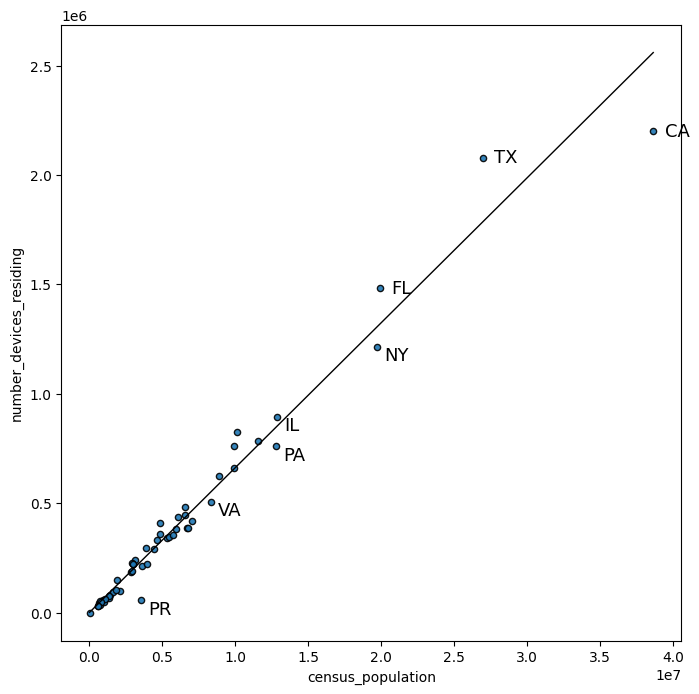

In [15]:
print("Figure 1: State-Level cennsus population vs residing device count for" , len(join_df_gb_state), "states availbale in our dataset")
xvar = 'census_population'
yvar = 'number_devices_residing'
ax = plot_sg_vs_census(join_df_gb_state,xvar,yvar,text_col='state',num_to_label=3,labelfontsize=13)
# Also plot PR and VA
for i, point in join_df_gb_state[join_df_gb_state.state.isin(['PR','VA', 'PA','IL','NY'])].iterrows():
      ax.text(point[xvar] + 9**6, point[yvar], str(point['state']),fontsize=13, verticalalignment='top')

In [16]:
# print states with largest absolute bias
join_df_gb_state['abs_bias'] = np.absolute(join_df_gb_state.bias)
join_df_gb_state.sort_values(by = 'abs_bias', ascending = False).head(20)

,state,census_block_group,census_population,number_devices_residing,state_fips,county_fips,county,bias,abs_bias
5,CA,0600140010010600140020010600140020020600140030...,38654206,2199795.0,0606060606060606060606060606060606060606060606...,0010010010010010010010010010010010010010010010...,Alameda CountyAlameda CountyAlameda CountyAlam...,-1.684998,1.684998
45,TX,4800195010014800195010024800195010034800195040...,26956435,2078585.0,4848484848484848484848484848484848484848484848...,0010010010010010010010010010010010010010010010...,Anderson CountyAnderson CountyAnderson CountyA...,1.378437,1.378437
40,PR,7200195630017200195630027200195640017200195640...,3529385,56992.0,7272727272727272727272727272727272727272727272...,0010010010010010010010010010010010010030030030...,Adjuntas MunicipioAdjuntas MunicipioAdjuntas M...,-0.828515,0.828515
10,FL,1200100020011200100020021200100020031200100020...,19934451,1481537.0,1212121212121212121212121212121212121212121212...,0010010010010010010010010010010010010010010010...,Alachua CountyAlachua CountyAlachua CountyAlac...,0.758670,0.758670
11,GA,1300195010011300195010021300195020011300195020...,10099320,825194.0,1313131313131313131313131313131313131313131313...,0010010010010010010010010010010010010010010030...,Appling CountyAppling CountyAppling CountyAppl...,0.734245,0.734245
28,NC,3700102010013700102010023700102010033700102010...,9940828,760450.0,3737373737373737373737373737373737373737373737...,0010010010010010010010010010010010010010010010...,Alamance CountyAlamance CountyAlamance CountyA...,0.479829,0.479829
35,NY,3600100010013600100010023600100020013600100020...,19697457,1214995.0,3636363636363636363636363636363636363636363636...,0010010010010010010010010010010010010010010010...,Albany CountyAlbany CountyAlbany CountyAlbany ...,-0.417724,0.417724
2,AL,0100102010010100102010020100102020010100102020...,4841164,408141.0,0101010101010101010101010101010101010101010101...,0010010010010010010010010010010010010010010010...,Autauga CountyAutauga CountyAutauga CountyAuta...,0.410958,0.410958
39,PA,4200103010114200103010214200103010224200103010...,12783977,761418.0,4242424242424242424242424242424242424242424242...,0010010010010010010010010010010010010010010010...,Adams CountyAdams CountyAdams CountyAdams Coun...,-0.398357,0.398357
4,AZ,0400194260010400194260020400194270010400194270...,6728577,387259.0,0404040404040404040404040404040404040404040404...,0010010010010010010010010010010010010010010010...,Apache CountyApache CountyApache CountyApache ...,-0.272964,0.272964


In [17]:
join_df_gb_county = join_df.groupby(['state', 'county']).sum().reset_index()
join_df_gb_county['bias'] = compute_bias(join_df_gb_county, sample_var_col='number_devices_residing' , pop_var_col='census_population')
#print(join_df_gb_county.shape)


Figure 2: County-Level cennsus population vs residing device count for 3219 counties availbale in our dataset
pearson r: 0.988
Sum Absolute Bias: 16.0339
Median Absolute Bias: 0.0014
Median Bias: -0.0005
Bias Standard Deviation: 0.0157


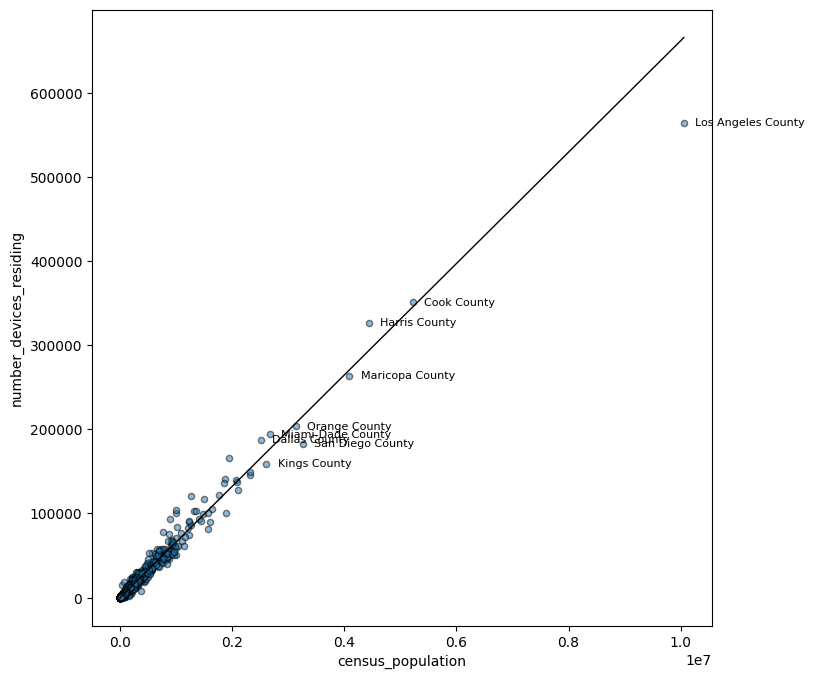

In [18]:
print("Figure 2: County-Level cennsus population vs residing device count for" , len(join_df_gb_county), "counties availbale in our dataset")
ax = plot_sg_vs_census(join_df_gb_county,'census_population','number_devices_residing', alpha = 0.5, text_col='county', num_to_label=9,labelfontsize=8)

In [19]:
# print counties with largest absolute bias
join_df_gb_county['abs_bias'] = np.absolute(join_df_gb_county.bias)
join_df_gb_county.sort_values(by = 'abs_bias', ascending = False).head(20)

,state,county,census_block_group,census_population,number_devices_residing,state_fips,county_fips,bias,abs_bias
204,CA,Los Angeles County,0603710111010603710111020603710111030603710112...,10057155,564266.0,0606060606060606060606060606060606060606060606...,0370370370370370370370370370370370370370370370...,-0.476311,0.476311
1745,NC,Wake County,3718305010013718305030013718305030023718305040...,998576,104012.0,3737373737373737373737373737373737373737373737...,1831831831831831831831831831831831831831831831...,0.177742,0.177742
367,FL,Orange County,1209501020011209501020021209501020031209501020...,1256055,120811.0,1212121212121212121212121212121212121212121212...,0950950950950950950950950950950950950950950950...,0.176582,0.176582
2819,TX,Tarrant County,4843910010114843910010124843910010134843910010...,1947529,165427.0,4848484848484848484848484848484848484848484848...,4394394394394394394394394394394394394394394394...,0.171128,0.171128
446,GA,Fulton County,1312100010011312100010021312100010031312100010...,996757,101014.0,1313131313131313131313131313131313131313131313...,1211211211211211211211211211211211211211211211...,0.164247,0.164247
2642,TX,Collin County,4808503010014808503010024808503010034808503020...,886633,93360.0,4848484848484848484848484848484848484848484848...,0850850850850850850850850850850850850850850850...,0.162544,0.162544
2700,TX,Harris County,4820110000014820110000024820110000034820121010...,4434257,326928.0,4848484848484848484848484848484848484848484848...,2012012012012012012012012012012012012012012012...,0.156436,0.156436
222,CA,San Diego County,0607300010010607300010020607300020110607300020...,3253356,183137.0,0606060606060606060606060606060606060606060606...,0730730730730730730730730730730730730730730730...,-0.151246,0.151246
2661,TX,Denton County,4812102010314812102010324812102010334812102010...,754650,77412.0,4848484848484848484848484848484848484848484848...,1211211211211211211211211211211211211211211211...,0.128731,0.128731
228,CA,Santa Clara County,0608550010010608550010020608550010030608550010...,1885056,100602.0,0606060606060606060606060606060606060606060606...,0850850850850850850850850850850850850850850850...,-0.113479,0.113479


In [20]:
join_df_cbg = join_df.copy()
join_df_cbg['bias'] = compute_bias(join_df_cbg, sample_var_col='number_devices_residing' , pop_var_col='census_population')
print(join_df_cbg.shape)


(220333, 8)


In [21]:
join_df_cbg.head()

,census_block_group,census_population,number_devices_residing,state_fips,county_fips,state,county,bias
0,010010201001,745,129.0,01,001,AL,Autauga County,0.000374
1,010010201002,1265,96.0,01,001,AL,Autauga County,0.000057
2,010010202001,960,48.0,01,001,AL,Autauga County,-0.000073
3,010010202002,1236,60.0,01,001,AL,Autauga County,-0.000102
4,010010203001,2364,174.0,01,001,AL,Autauga County,0.000082


Figure 3: Census Block Group-Level  cennsus population vs residing device count for 220333 CBGs availbale in our dataset
pearson r: 0.447
Sum Absolute Bias: 45.3792
Median Absolute Bias: 0.0001
Median Bias: -0.0001
Bias Standard Deviation: 0.0006


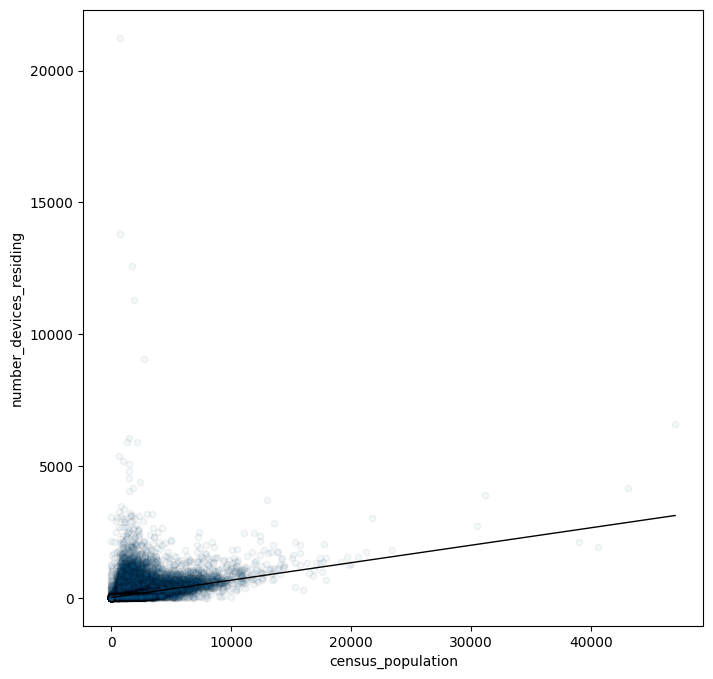

In [22]:
print("Figure 3: Census Block Group-Level  cennsus population vs residing device count for", len(join_df_cbg), "CBGs availbale in our dataset")
alpha_level = 0.05 # transparency of points (0,1)
ax = plot_sg_vs_census(join_df_cbg,'census_population','number_devices_residing', alpha = alpha_level,num_to_label=0)

In [23]:
# print cbgs with largest absolute bias
join_df_cbg['abs_bias'] = np.absolute(join_df_cbg.bias)
join_df_cbg.sort_values(by = 'abs_bias', ascending = False).head(5)

,census_block_group,census_population,number_devices_residing,state_fips,county_fips,state,county,bias,abs_bias
54717,131210035001,726,21250.0,13,121,GA,Fulton County,0.099429,0.099429
78036,201550018002,717,13778.0,20,155,KS,Reno County,0.064391,0.064391
74586,190570010001,1703,12578.0,19,057,IA,Des Moines County,0.058457,0.058457
151239,390351077011,1890,11295.0,39,035,OH,Cuyahoga County,0.052382,0.052382
135510,360610031001,2744,9046.0,36,061,NY,New York County,0.041570,0.041570


Figure 4: CBG Data excluding the most biased points

Using bias threshold of: 0.001
Number of CBGs excluded with bias > threshold: 5227
Number of CBGs retained: 215106
Sum of `number_devices_residing` for excluded CBGs: 3719808.0

Plotting with transparency_level: 0.002/1

pearson r: 0.771
Sum Absolute Bias: 31.6212
Median Absolute Bias: 0.0001
Median Bias: -0.0001
Bias Standard Deviation: 0.0002


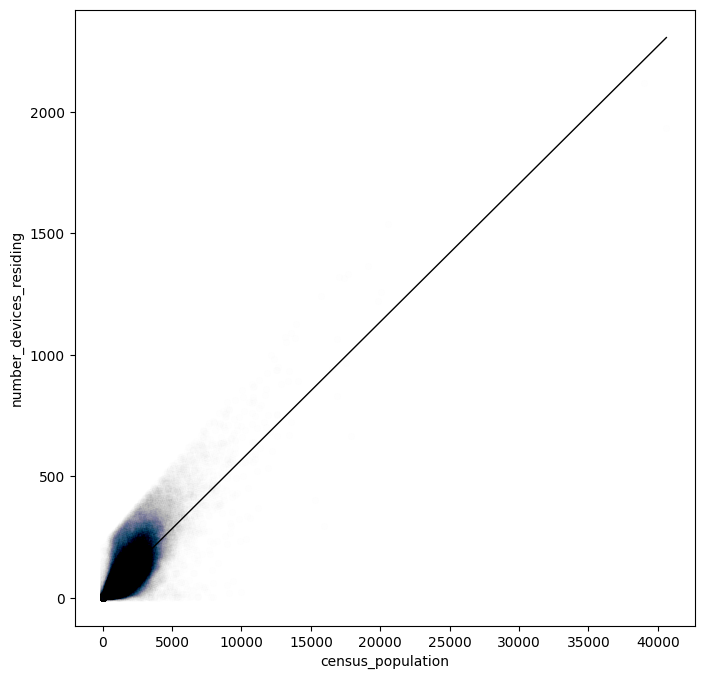

In [24]:
print("Figure 4: CBG Data excluding the most biased points")
print("")
transparency_level = 0.002
bias_threshold = 0.001
print("Using bias threshold of: {0}".format(bias_threshold))
print("Number of CBGs excluded with bias > threshold: {0}".format(join_df_cbg[join_df_cbg.bias > bias_threshold].shape[0]))
print("Number of CBGs retained: {0}".format(join_df_cbg[join_df_cbg.bias < bias_threshold].shape[0]))
print("Sum of `number_devices_residing` for excluded CBGs: {0}".format(join_df_cbg[join_df_cbg.bias > bias_threshold].number_devices_residing.sum()))
print("\nPlotting with transparency_level: {0}/1".format(transparency_level))
print("")
ax = plot_sg_vs_census(join_df_cbg[join_df_cbg.bias < bias_threshold],'census_population','number_devices_residing', alpha = transparency_level ,num_to_label=0)

In [25]:
def sum_and_wrangle_demo_counts(df, demo_code_list):
  # this function tidy's the data into expected form for visualization functions
  
  # sum each demo category across all CBGs 
  columns_to_sum = demo_code_list + [dc + '_panel' for dc in demo_code_list]
  summs = pd.DataFrame(df[columns_to_sum].sum()).reset_index()
  summs.columns = ['demo_code','count']
  
  # data wrangle to get into correct format for visualization
  summs['panel'] = summs.demo_code.str.contains('panel')
  summs['table_id'] = summs.demo_code.str.split("_").str[0]
  summs = pd.merge(summs[summs.panel], summs[~summs.panel], on='table_id', suffixes=('_panel', '_census'))
  summs = summs[['table_id', 'count_census','count_panel']]
  return(summs)

In [26]:
race_census_data = read_csv_with_cbg(DATA_DIR / 'cbg_b02.csv')
race_census_data['census_block_group'] = normalize_cbg(race_census_data['census_block_group'])
race_table_ids = ['B02001e2','B02001e3','B02001e4','B02001e5','B02001e6','B02001e7','B02001e8']
columns = ['census_block_group'] + race_table_ids
race_census_data = race_census_data[columns]


In [27]:
join_df_race = pd.merge(join_df,race_census_data)

# allocate panel count into demo categories with proportions dictated by census
for census_id in race_table_ids: 
  # demo-group panel_count = (devices in this CBG)* (fraction of demo-group in CBG)
  join_df_race[census_id + '_panel'] = join_df_race['number_devices_residing'] * join_df_race[census_id]/join_df_race['census_population']

# sum across all CBGs
summs_race = sum_and_wrangle_demo_counts(join_df_race, race_table_ids)

# bring in census labels
summs_race = pd.merge(summs_race, cbg_field_desc[['table_id', 'field_level_2']])
summs_race['bias'] = compute_bias(summs_race, sample_var_col='count_panel' , pop_var_col='count_census')
summs_race.head(10)

,table_id,count_census,count_panel,field_level_2,bias
0,B02001e2,236105163.0,1.584054e+07,White Alone,1.082529
1,B02001e3,40561905.0,2.644022e+06,Black Or African American Alone,-0.177110
2,B02001e4,2609631.0,1.393749e+05,American Indian And Alaska Native Alone,-0.155719
3,B02001e5,16624199.0,1.085835e+06,Asian Alone,-0.062309
4,B02001e6,560203.0,3.231552e+04,Native Hawaiian And Other Pacific Islander Alone,-0.022175
5,B02001e7,15608735.0,9.106126e+05,Some Other Race Alone,-0.569878
6,B02001e8,10017711.0,6.420159e+05,Two Or More Races,-0.095337


Figure 5: Race-Level cennsus population vs residing device count for 7 racial groups by census
pearson r: 1.000
Sum Absolute Bias: 2.1651
Median Absolute Bias: 0.1557
Median Bias: -0.0953
Bias Standard Deviation: 0.5108


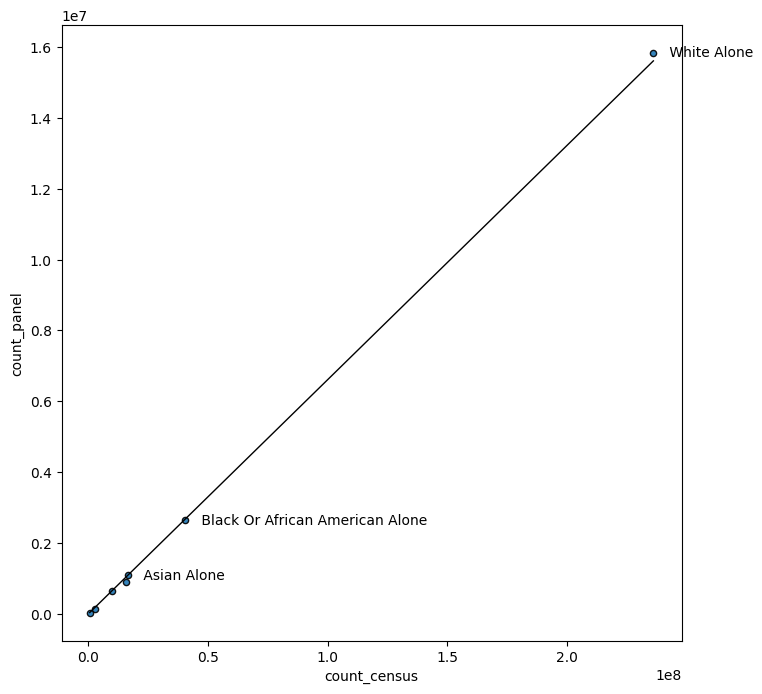

In [28]:
print("Figure 5: Race-Level cennsus population vs residing device count for" , len(summs_race), "racial groups by census")
ax = plot_sg_vs_census(summs_race,'count_census','count_panel', text_col = 'field_level_2', labelfontsize=10, num_to_label=3)

In [29]:
edu_census_data = read_csv_with_cbg(DATA_DIR / 'cbg_b15.csv')
edu_census_data['census_block_group'] = normalize_cbg(edu_census_data['census_block_group'])
edu_table_ids = ['B15003e10','B15003e11','B15003e12','B15003e13','B15003e14','B15003e15','B15003e16','B15003e17','B15003e18','B15003e19','B15003e2','B15003e20','B15003e21','B15003e22','B15003e23','B15003e24','B15003e25','B15003e3','B15003e4','B15003e5','B15003e6','B15003e7','B15003e8','B15003e9']
columns = ['census_block_group'] + edu_table_ids
edu_census_data = edu_census_data[columns]


In [30]:
join_df_edu = pd.merge(join_df,edu_census_data)

# allocate panel count into demo categories with proportions dictated by the census
for census_id in edu_table_ids: 
  # demo-group panel_count = (devices in this CBG)* (fraction of demo-group in CBG) census block group
  join_df_edu[census_id + '_panel'] = join_df_edu['number_devices_residing'] * join_df_edu[census_id]/join_df_edu['census_population']


# sum across all CBGs
summs_edu = sum_and_wrangle_demo_counts(join_df_edu, edu_table_ids)

# bring in census labels
summs_edu = pd.merge(summs_edu, cbg_field_desc[['table_id', 'field_level_2']])
summs_edu['bias'] = compute_bias(summs_edu, sample_var_col='count_panel' , pop_var_col='count_census')
summs_edu['abs_bias'] =  np.absolute(summs_edu.bias)
summs_edu.sort_values(by='abs_bias', ascending = False).head(10)

,table_id,count_census,count_panel,field_level_2,bias,abs_bias
13,B15003e22,40615005.0,2.838926e+06,Bachelor'S Degree,0.940348,0.940348
7,B15003e17,50883643.0,3.316036e+06,Regular High School Diploma,-0.495141,0.495141
14,B15003e23,17563374.0,1.220575e+06,Master'S Degree,0.357430,0.357430
0,B15003e10,2749241.0,1.562767e+05,6Th Grade,-0.185895,0.185895
3,B15003e13,3543757.0,2.130014e+05,9Th Grade,-0.159231,0.159231
2,B15003e12,2934250.0,1.743774e+05,8Th Grade,-0.145673,0.145673
5,B15003e15,4639575.0,2.881217e+05,11Th Grade,-0.144120,0.144120
8,B15003e18,8594305.0,5.550041e+05,Ged Or Alternative Credential,-0.118938,0.118938
9,B15003e19,13388406.0,9.083035e+05,"Some College, Less Than 1 Year",0.118596,0.118596
11,B15003e20,31685213.0,2.125962e+06,"Some College, 1 Or More Years, No Degree",0.116281,0.116281


Figure 6: Educationl Attainment-Level cennsus vs residing device count for 24 education level groups by census
pearson r: 0.999
Sum Absolute Bias: 3.5581
Median Absolute Bias: 0.1142
Median Bias: -0.0440
Bias Standard Deviation: 0.2525


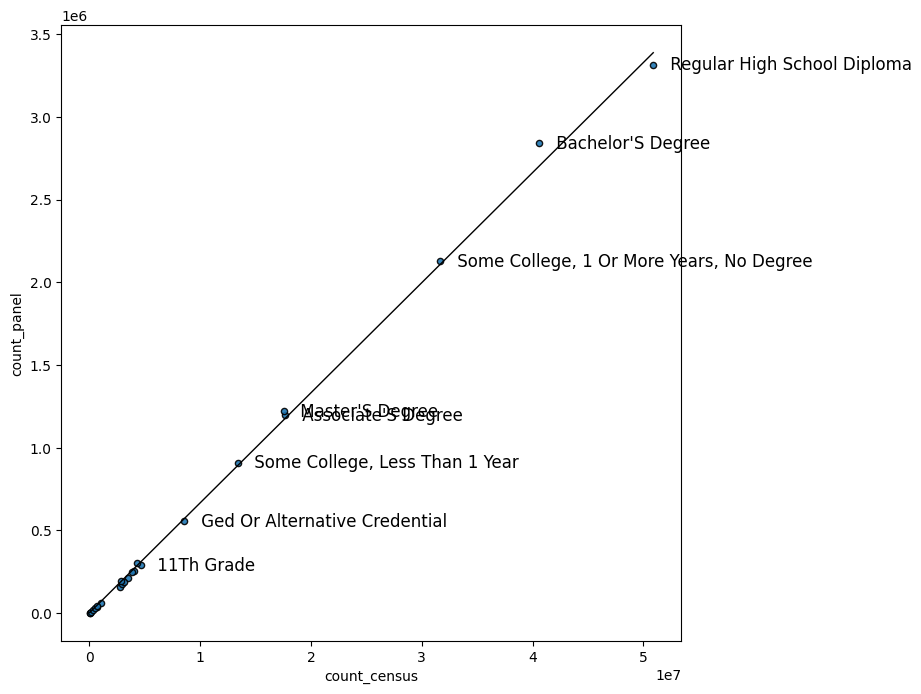

In [31]:
print("Figure 6: Educationl Attainment-Level cennsus vs residing device count for" , len(summs_edu), "education level groups by census")
ax = plot_sg_vs_census(summs_edu,'count_census','count_panel', text_col='field_level_2',labelfontsize=12,num_to_label=8)

In [32]:
inc_census_data = read_csv_with_cbg(DATA_DIR / 'cbg_b19.csv')
inc_census_data['census_block_group'] = normalize_cbg(inc_census_data['census_block_group'])

join_df_inc = pd.merge(join_df,inc_census_data)


In [33]:
inc_table_ids = ['B19001e10', 'B19001e11', 'B19001e12', 'B19001e13', 'B19001e14', 'B19001e15', 'B19001e16', 'B19001e17', 'B19001e2', 'B19001e3', 'B19001e4', 'B19001e5', 'B19001e6', 'B19001e7', 'B19001e8', 'B19001e9']

In [34]:
join_df_inc['census_population'] = join_df_inc[inc_table_ids].sum(axis=1) # total number of households <> total population, so we will re-define census_population to be total households

# allocate panel count into demo categories with proportions dictated by the census
for census_id in inc_table_ids: 
  # demo-group panel_count = (devices in this CBG)* (fraction of demo-group in CBG) census block group
  join_df_inc[census_id + '_panel'] = join_df_inc['number_devices_residing'] * join_df_inc[census_id]/join_df_inc['census_population']

# sum across all CBGs
summs_inc_raw = sum_and_wrangle_demo_counts(join_df_inc, inc_table_ids)

# bring in census labels
summs_inc = pd.merge(summs_inc_raw, cbg_field_desc[['table_id', 'field_level_2']])

summs_inc['bias'] = compute_bias(summs_inc, sample_var_col='count_panel' , pop_var_col='count_census')
summs_inc['abs_bias'] =  np.absolute(summs_inc.bias)
summs_inc.sort_values(by='abs_bias', ascending = False).head(10)

/var/folders/hn/dnl2pg8s6x56lw8mp1p54cwm0000gn/T/ipykernel_7386/421297192.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  join_df_inc[census_id + '_panel'] = join_df_inc['number_devices_residing'] * join_df_inc[census_id]/join_df_inc['census_population']


,table_id,count_census,count_panel,field_level_2,bias,abs_bias
8,B19001e2,8599376.0,1.410134e+06,"Less Than $10,000",-0.600151,0.600151
7,B19001e17,6679555.0,1.310936e+06,"$200,000 Or More",0.547443,0.547443
6,B19001e16,6379471.0,1.252152e+06,"$150,000 To $199,999",0.523369,0.523369
4,B19001e14,9878597.0,1.877354e+06,"$100,000 To $124,999",0.520852,0.520852
9,B19001e3,6145521.0,1.006875e+06,"$10,000 To $14,999",-0.433003,0.433003
5,B19001e15,6039066.0,1.170110e+06,"$125,000 To $149,999",0.423855,0.423855
3,B19001e13,14407504.0,2.665682e+06,"$75,000 To $99,999",0.419489,0.419489
10,B19001e4,6085613.0,1.014168e+06,"$15,000 To $19,999",-0.348355,0.348355
11,B19001e5,6194566.0,1.047025e+06,"$20,000 To $24,999",-0.285488,0.285488
12,B19001e6,5853087.0,9.947942e+05,"$25,000 To $29,999",-0.243956,0.243956


Figure 7: Household Income for 16 levels of income
pearson r: 0.989
Sum Absolute Bias: 4.9783
Median Absolute Bias: 0.3169
Median Bias: -0.0864
Bias Standard Deviation: 0.3736


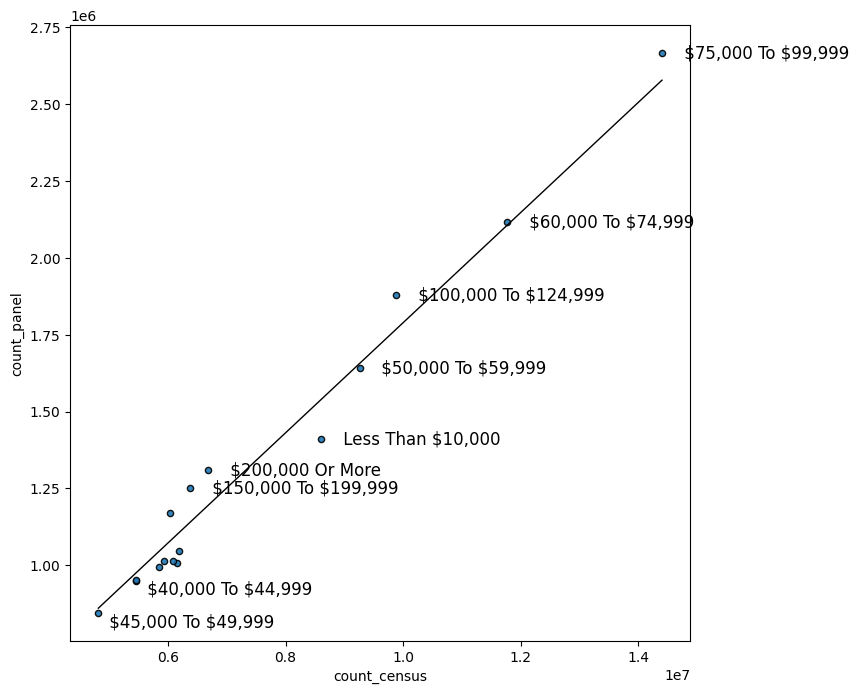

In [35]:
print("Figure 7: Household Income for", len(summs_inc), "levels of income")

xvar = 'count_census'
yvar = 'count_panel'
label_col = 'labels'
labelfontsize = 12

summs_inc['labels'] = summs_inc.field_level_2.str.replace(pat='$',repl='\$', regex=False)
ax = plot_sg_vs_census(summs_inc,xvar,yvar, text_col=label_col,labelfontsize=labelfontsize,num_to_label=7)

# Plot a few more levels
for i, point in summs_inc[summs_inc.table_id.isin(['B19001e10','B19001e9'])].iterrows():
      ax.text(point[xvar]*1.02, point[yvar], str(point[label_col]),fontsize=labelfontsize, verticalalignment='top')


Figure 7: Uncorrected Census Block Group-Level Scatter Plot 
(same data as Figure 3)

pearson r: 0.447
Sum Absolute Bias: 45.3792
Median Absolute Bias: 0.0001
Median Bias: -0.0001
Bias Standard Deviation: 0.0006


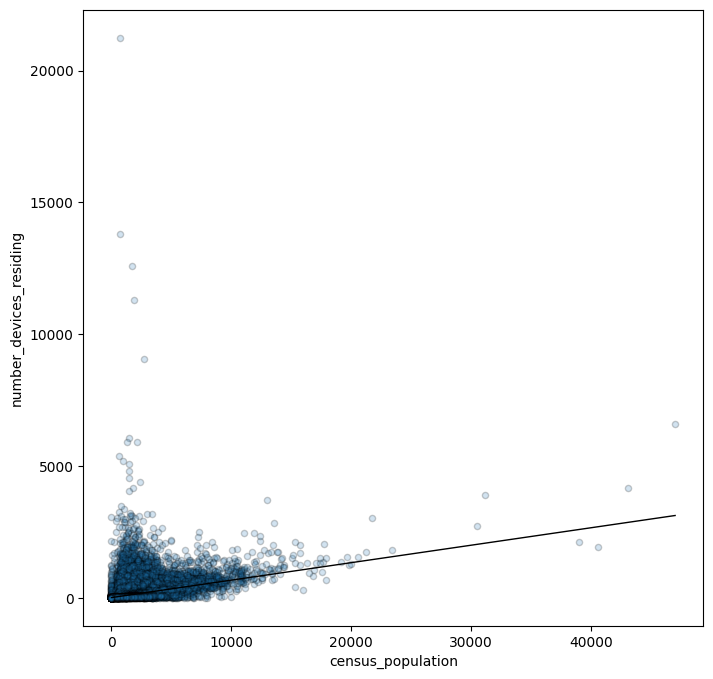

In [36]:
print("Figure 7: Uncorrected Census Block Group-Level Scatter Plot \n(same data as Figure 3)\n")
ax = plot_sg_vs_census(join_df_cbg,'census_population','number_devices_residing', alpha = 0.2,num_to_label=0)

Figure 8: Adjusted Census Block Group-Level Sampling

pearson r: 1.000
Sum Absolute Bias: 0.0321
Median Absolute Bias: 0.0000
Median Bias: 0.0000
Bias Standard Deviation: 0.0000


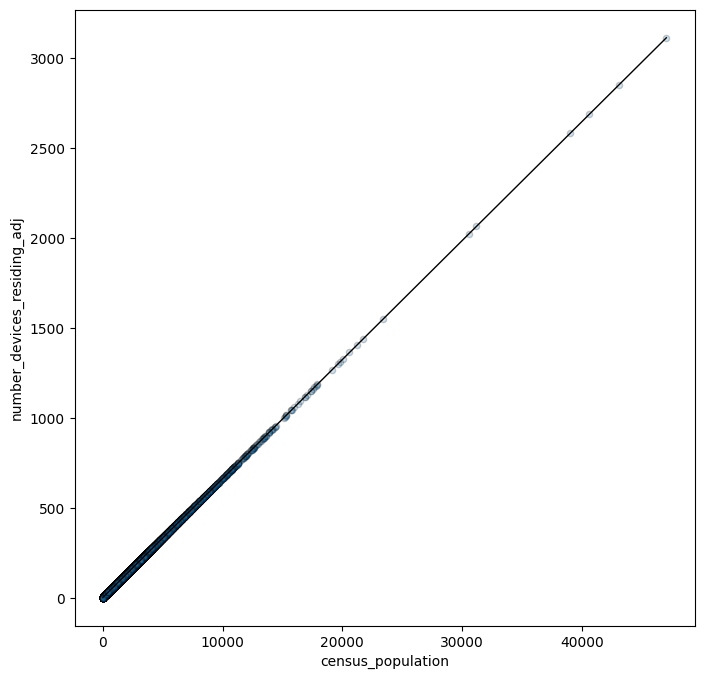

In [37]:
print("Figure 8: Adjusted Census Block Group-Level Sampling\n")
join_df_cbg_adj = join_df_cbg.copy()
join_df_cbg_adj['cbg_adjust_factor'] = join_df_cbg_adj.census_population / join_df_cbg_adj.census_population.sum() * join_df_cbg_adj.number_devices_residing.sum() / join_df_cbg_adj.number_devices_residing
join_df_cbg_adj['number_devices_residing_adj'] = join_df_cbg_adj.number_devices_residing * join_df_cbg_adj.cbg_adjust_factor
join_df_cbg_adj['bias'] = compute_bias(join_df_cbg_adj, sample_var_col='number_devices_residing_adj' , pop_var_col='census_population')

ax = plot_sg_vs_census(join_df_cbg_adj,'census_population','number_devices_residing_adj', alpha = 0.2, num_to_label=0)


## NYC CBG-level representativeness analysis

The original notebook mainly checks national/state/county representativeness. The following cells keep that analysis unchanged and add a New York City CBG-level section.

NYC is defined as the five borough counties: Bronx, Brooklyn/Kings, Manhattan/New York, Queens, and Staten Island/Richmond.

In [39]:
# Build NYC-only CBG table from the national join_df
nyc_join_df = join_df[
    (join_df['state_fips'] == NY_STATE_FIPS) &
    (join_df['county_fips'].isin(NYC_COUNTY_FIPS.keys()))
].copy()

nyc_join_df['borough'] = nyc_join_df['county_fips'].map(NYC_COUNTY_FIPS)
nyc_join_df = add_representativeness_metrics(
    nyc_join_df,
    sample_col='number_devices_residing',
    pop_col='census_population'
)

nyc_summary = pd.DataFrame({
    'metric': [
        'NYC CBG count',
        'NYC Census population',
        'NYC SafeGraph residing devices',
        'Devices per 100 residents',
        'CBGs with 0 or missing SafeGraph devices',
        'Population in CBGs with 0 or missing SafeGraph devices',
        'Share of NYC population in CBGs with 0 or missing SafeGraph devices'
    ],
    'value': [
        len(nyc_join_df),
        nyc_join_df['census_population'].sum(),
        nyc_join_df['number_devices_residing'].sum(),
        nyc_join_df['number_devices_residing'].sum() / nyc_join_df['census_population'].sum() * 100,
        (nyc_join_df['number_devices_residing'] == 0).sum(),
        nyc_join_df.loc[nyc_join_df['number_devices_residing'] == 0, 'census_population'].sum(),
        nyc_join_df.loc[nyc_join_df['number_devices_residing'] == 0, 'census_population'].sum() / nyc_join_df['census_population'].sum()
    ]
})

display(nyc_summary)
display(nyc_join_df.head())

,metric,value
0,NYC CBG count,6.493000e+03
1,NYC Census population,8.461961e+06
2,NYC SafeGraph residing devices,5.461630e+05
3,Devices per 100 residents,6.454331e+00
4,CBGs with 0 or missing SafeGraph devices,1.340000e+02
5,Population in CBGs with 0 or missing SafeGraph...,0.000000e+00
6,Share of NYC population in CBGs with 0 or miss...,0.000000e+00


,census_block_group,census_population,number_devices_residing,state_fips,county_fips,state,county,borough,bias,abs_bias,expected_devices_if_representative,device_count_gap,devices_per_100_residents,representation_ratio,log_representation_ratio
127969,360050001000,0,1.0,36,005,NY,Bronx County,Bronx,0.000183,0.000183,0.000000,1.000000,NaN,inf,inf
127970,360050001001,7503,21.0,36,005,NY,Bronx County,Bronx,-0.084822,0.084822,484.268480,-463.268480,0.279888,0.043364,-3.138117
127971,360050002000,0,0.0,36,005,NY,Bronx County,Bronx,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
127972,360050002001,2114,53.0,36,005,NY,Bronx County,Bronx,-0.015278,0.015278,136.444564,-83.444564,2.507096,0.388436,-0.945626
127973,360050002002,2168,99.0,36,005,NY,Bronx County,Bronx,-0.007494,0.007494,139.929903,-40.929903,4.566421,0.707497,-0.346022


### NYC CBG sensitivity filter

Some NYC CBGs have extremely small Census residential populations but non-trivial SafeGraph device counts. These CBGs can create very large representation ratios and can distort interpretation. The following filter keeps the full NYC CBG table unchanged, then creates a filtered residential-CBG version for robustness checks.


In [41]:
# Sensitivity filter: remove tiny-population / unstable CBGs
MIN_CBG_POP = 100
MIN_CBG_DEVICES = 5

nyc_join_df_filtered = nyc_join_df[
    (nyc_join_df['census_population'] >= MIN_CBG_POP) &
    (nyc_join_df['number_devices_residing'] >= MIN_CBG_DEVICES) &
    np.isfinite(nyc_join_df['representation_ratio'])
].copy()

# Recompute representativeness metrics within the filtered residential-CBG universe.
# This avoids carrying over ratios that were calculated against the full NYC denominator.
nyc_join_df_filtered = add_representativeness_metrics(
    nyc_join_df_filtered,
    sample_col='number_devices_residing',
    pop_col='census_population'
)

nyc_sensitivity_summary = pd.DataFrame({
    'metric': [
        'All NYC CBGs',
        'Filtered residential CBGs',
        'CBGs removed by filter',
        'Population retained',
        'Population removed',
        'Share of population retained',
        'SafeGraph devices retained',
        'SafeGraph devices removed',
        'Share of SafeGraph devices retained',
        'Minimum CBG population threshold',
        'Minimum SafeGraph device threshold'
    ],
    'value': [
        len(nyc_join_df),
        len(nyc_join_df_filtered),
        len(nyc_join_df) - len(nyc_join_df_filtered),
        nyc_join_df_filtered['census_population'].sum(),
        nyc_join_df['census_population'].sum() - nyc_join_df_filtered['census_population'].sum(),
        nyc_join_df_filtered['census_population'].sum() / nyc_join_df['census_population'].sum(),
        nyc_join_df_filtered['number_devices_residing'].sum(),
        nyc_join_df['number_devices_residing'].sum() - nyc_join_df_filtered['number_devices_residing'].sum(),
        nyc_join_df_filtered['number_devices_residing'].sum() / nyc_join_df['number_devices_residing'].sum(),
        MIN_CBG_POP,
        MIN_CBG_DEVICES
    ]
})

display(nyc_sensitivity_summary)
display(nyc_join_df_filtered.head())


,metric,value
0,All NYC CBGs,6.493000e+03
1,Filtered residential CBGs,6.186000e+03
2,CBGs removed by filter,3.070000e+02
3,Population retained,8.448699e+06
4,Population removed,1.326200e+04
5,Share of population retained,9.984328e-01
6,SafeGraph devices retained,5.312040e+05
7,SafeGraph devices removed,1.495900e+04
8,Share of SafeGraph devices retained,9.726107e-01
9,Minimum CBG population threshold,1.000000e+02


,census_block_group,census_population,number_devices_residing,state_fips,county_fips,state,county,borough,bias,abs_bias,expected_devices_if_representative,device_count_gap,devices_per_100_residents,representation_ratio,log_representation_ratio
127970,360050001001,7503,21.0,36,005,NY,Bronx County,Bronx,-0.084853,0.084853,471.744065,-450.744065,0.279888,0.044516,-3.111914
127972,360050002001,2114,53.0,36,005,NY,Bronx County,Bronx,-0.015044,0.015044,132.915761,-79.915761,2.507096,0.398749,-0.919424
127973,360050002002,2168,99.0,36,005,NY,Bronx County,Bronx,-0.007024,0.007024,136.310960,-37.310960,4.566421,0.726281,-0.319819
127974,360050002003,969,68.0,36,005,NY,Bronx County,Bronx,0.001332,0.001332,60.924963,7.075037,7.017544,1.116127,0.109865
127976,360050004001,646,41.0,36,005,NY,Bronx County,Bronx,0.000072,0.000072,40.616642,0.383358,6.346749,1.009438,0.009394


NYC Figure A: CBG-level Census population vs SafeGraph residing devices
pearson r: 0.168
Sum Absolute Bias: 50.0372
Median Absolute Bias: 0.0039
Median Bias: -0.0026
Bias Standard Deviation: 0.0338


Text(0, 0.5, 'SafeGraph residing devices')

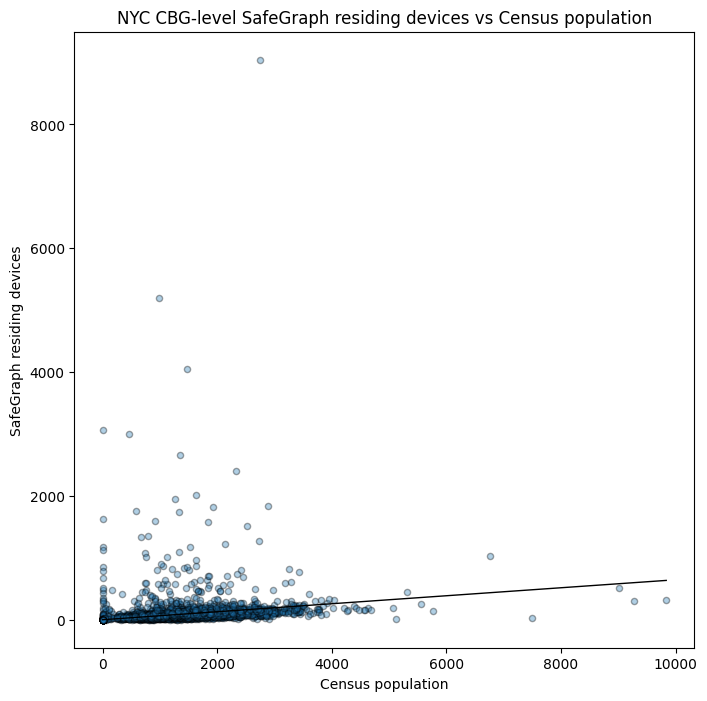

In [42]:
print("NYC Figure A: CBG-level Census population vs SafeGraph residing devices")
ax = plot_sg_vs_census(
    nyc_join_df,
    'census_population',
    'number_devices_residing',
    text_col='borough',
    num_to_label=0,
    alpha=0.35,
    labelfontsize=9,
    title='NYC CBG-level SafeGraph residing devices vs Census population'
)
ax.set_xlabel('Census population')
ax.set_ylabel('SafeGraph residing devices')

,borough,cbg_count,census_population,number_devices_residing,devices_per_100_residents,bias,representation_ratio,device_count_gap
4,Staten Island,338,473324,41341.0,8.734186,1.975802,1.353229,10791.100773
3,Queens,1746,2310011,149237.0,6.460445,0.025860,1.000947,141.236288
2,Manhattan,1170,1634989,104892.0,6.415456,-0.116377,0.993977,-635.607278
0,Bronx,1154,1436785,91493.0,6.367898,-0.227380,0.986608,-1241.864407
1,Brooklyn,2085,2606852,159200.0,6.106983,-1.657905,0.946184,-9054.865376


NYC Figure B: Borough-level representativeness
pearson r: 0.998
Sum Absolute Bias: 4.0033
Median Absolute Bias: 0.2274
Median Bias: -0.1164
Bias Standard Deviation: 1.2960


Text(0, 0.5, 'SafeGraph residing devices')

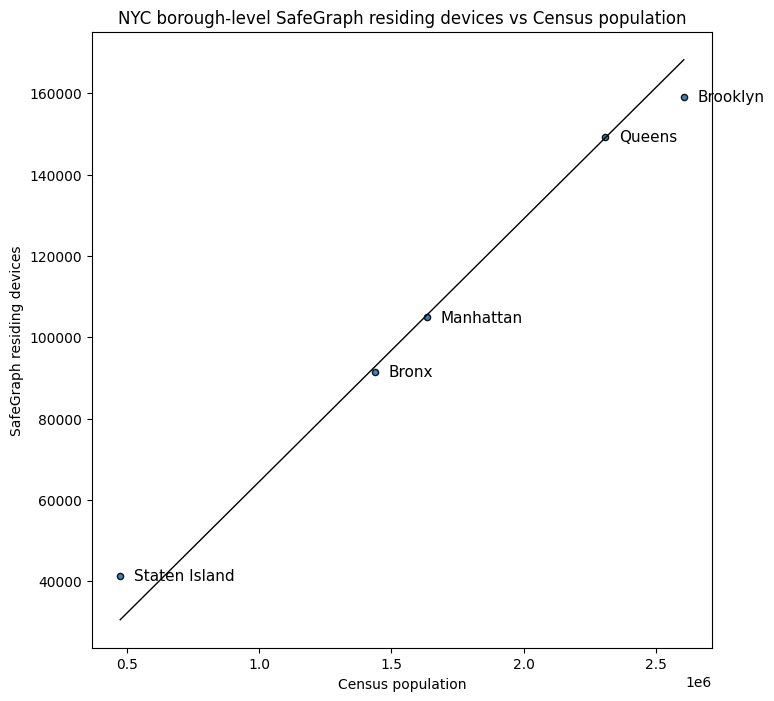

In [43]:
# Borough-level aggregation
nyc_borough = (
    nyc_join_df
    .groupby(['borough', 'state_fips', 'county_fips'], as_index=False)
    .agg(
        census_population=('census_population', 'sum'),
        number_devices_residing=('number_devices_residing', 'sum'),
        cbg_count=('census_block_group', 'nunique')
    )
)

nyc_borough = add_representativeness_metrics(
    nyc_borough,
    sample_col='number_devices_residing',
    pop_col='census_population'
).sort_values('representation_ratio', ascending=False)

display(nyc_borough[['borough', 'cbg_count', 'census_population', 'number_devices_residing',
                     'devices_per_100_residents', 'bias', 'representation_ratio',
                     'device_count_gap']])

print("NYC Figure B: Borough-level representativeness")
ax = plot_sg_vs_census(
    nyc_borough,
    'census_population',
    'number_devices_residing',
    text_col='borough',
    num_to_label=len(nyc_borough),
    alpha=0.9,
    labelfontsize=11,
    title='NYC borough-level SafeGraph residing devices vs Census population'
)
ax.set_xlabel('Census population')
ax.set_ylabel('SafeGraph residing devices')

### NYC borough-level sensitivity results

This repeats the borough-level summary after excluding tiny-population or very-low-device CBGs. Use this table as a robustness check for the main borough-level result.


,borough,cbg_count,census_population,number_devices_residing,devices_per_100_residents,bias,representation_ratio,device_count_gap
4,Staten Island,304,473184,41280.0,8.723879,2.170353,1.387516,11529.001232
3,Queens,1678,2309318,148170.0,6.416180,0.559823,1.020481,2973.803654
0,Bronx,1108,1435639,89112.0,6.207131,-0.216951,0.987233,-1152.451291
1,Brooklyn,2022,2595690,155565.0,5.993204,-1.437596,0.953208,-7636.566390
2,Manhattan,1074,1634868,97077.0,5.937911,-1.075630,0.944413,-5713.787205


NYC Figure B2: Borough-level representativeness after sensitivity filter
pearson r: 0.994
Sum Absolute Bias: 5.4604
Median Absolute Bias: 1.0756
Median Bias: -0.2170
Bias Standard Deviation: 1.4400


Text(0, 0.5, 'SafeGraph residing devices, filtered CBGs')

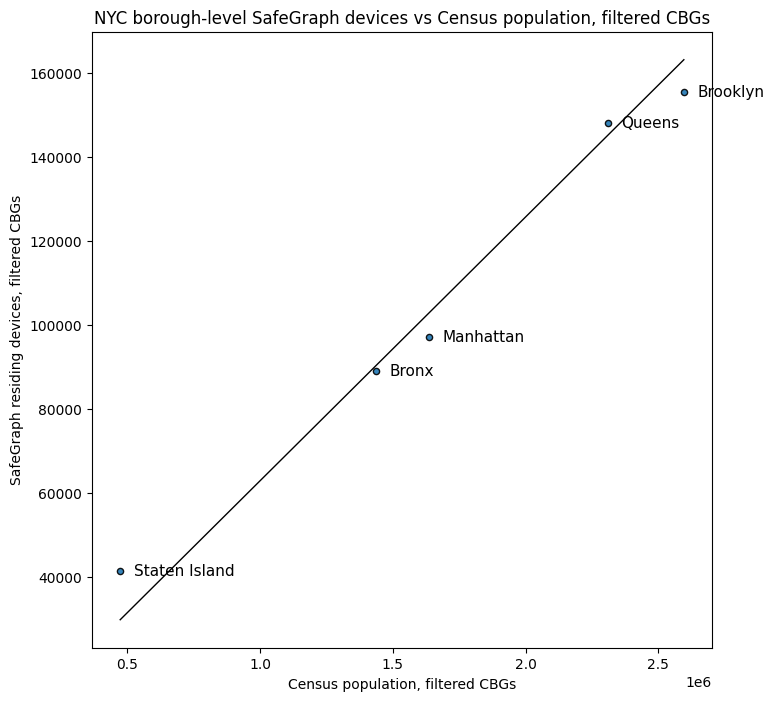

In [45]:
# Borough-level aggregation after sensitivity filtering
nyc_borough_filtered = (
    nyc_join_df_filtered
    .groupby(['borough', 'state_fips', 'county_fips'], as_index=False)
    .agg(
        census_population=('census_population', 'sum'),
        number_devices_residing=('number_devices_residing', 'sum'),
        cbg_count=('census_block_group', 'nunique')
    )
)

nyc_borough_filtered = add_representativeness_metrics(
    nyc_borough_filtered,
    sample_col='number_devices_residing',
    pop_col='census_population'
).sort_values('representation_ratio', ascending=False)

display(nyc_borough_filtered[['borough', 'cbg_count', 'census_population', 'number_devices_residing',
                              'devices_per_100_residents', 'bias', 'representation_ratio',
                              'device_count_gap']])

print("NYC Figure B2: Borough-level representativeness after sensitivity filter")
ax = plot_sg_vs_census(
    nyc_borough_filtered,
    'census_population',
    'number_devices_residing',
    text_col='borough',
    num_to_label=len(nyc_borough_filtered),
    alpha=0.9,
    labelfontsize=11,
    title='NYC borough-level SafeGraph devices vs Census population, filtered CBGs'
)
ax.set_xlabel('Census population, filtered CBGs')
ax.set_ylabel('SafeGraph residing devices, filtered CBGs')


In [46]:
# Most over- and under-represented NYC CBGs by representation ratio and device-count gap.
# Use the filtered residential-CBG version to avoid tiny-CBG instability.
nyc_rankable = nyc_join_df_filtered[
    (nyc_join_df_filtered['representation_ratio'].notna()) &
    np.isfinite(nyc_join_df_filtered['representation_ratio'])
].copy()

print(f"Ranking NYC CBGs after sensitivity filter: census_population >= {MIN_CBG_POP:,} and devices >= {MIN_CBG_DEVICES:,}.")
print("\nTop 15 over-represented NYC CBGs by representation_ratio:")
display(
    nyc_rankable.sort_values('representation_ratio', ascending=False)
    [['census_block_group', 'borough', 'census_population', 'number_devices_residing',
      'expected_devices_if_representative', 'representation_ratio', 'device_count_gap']]
    .head(15)
)

print("\nTop 15 under-represented NYC CBGs by representation_ratio:")
display(
    nyc_rankable.sort_values('representation_ratio', ascending=True)
    [['census_block_group', 'borough', 'census_population', 'number_devices_residing',
      'expected_devices_if_representative', 'representation_ratio', 'device_count_gap']]
    .head(15)
)

print("\nTop 15 positive device-count gaps:")
display(
    nyc_rankable.sort_values('device_count_gap', ascending=False)
    [['census_block_group', 'borough', 'census_population', 'number_devices_residing',
      'expected_devices_if_representative', 'representation_ratio', 'device_count_gap']]
    .head(15)
)

print("\nTop 15 negative device-count gaps:")
display(
    nyc_rankable.sort_values('device_count_gap', ascending=True)
    [['census_block_group', 'borough', 'census_population', 'number_devices_residing',
      'expected_devices_if_representative', 'representation_ratio', 'device_count_gap']]
    .head(15)
)


Ranking NYC CBGs after sensitivity filter: census_population >= 100 and devices >= 5.

Top 15 over-represented NYC CBGs by representation_ratio:


,census_block_group,borough,census_population,number_devices_residing,expected_devices_if_representative,representation_ratio,device_count_gap
132376,360470385002,Brooklyn,469,3001.0,29.487934,101.770440,2971.512066
132158,360470301003,Brooklyn,988,5190.0,62.119570,83.548550,5127.880430
135510,360610031001,Manhattan,2744,9046.0,172.526418,52.432550,8873.473582
138922,360810629003,Queens,581,1752.0,36.529828,47.960806,1715.470172
138943,360810641021,Queens,172,486.0,10.814338,44.940337,475.185662
128748,360050334001,Bronx,1468,4043.0,92.299119,43.803235,3950.700881
133401,360471144004,Brooklyn,673,1330.0,42.314242,31.431498,1287.685758
133465,360471196001,Brooklyn,1350,2657.0,84.879980,31.303023,2572.120020
136038,360610154007,Manhattan,909,1602.0,57.152520,28.030260,1544.847480
132886,360470591004,Brooklyn,797,1350.0,50.110625,26.940394,1299.889375



Top 15 under-represented NYC CBGs by representation_ratio:


,census_block_group,borough,census_population,number_devices_residing,expected_devices_if_representative,representation_ratio,device_count_gap
132682,360470509002,Brooklyn,2911,5.0,183.026386,0.027318,-178.026386
127970,360050001001,Bronx,7503,21.0,471.744065,0.044516,-450.744065
132745,360470531001,Brooklyn,5128,16.0,322.418175,0.049625,-306.418175
132760,360470535001,Brooklyn,1354,6.0,85.131476,0.070479,-79.131476
131909,360470216002,Brooklyn,1530,7.0,96.197310,0.072767,-89.197310
131952,360470232001,Brooklyn,1475,7.0,92.739237,0.075480,-85.739237
132741,360470529003,Brooklyn,1245,6.0,78.278204,0.076650,-72.278204
132754,360470533004,Brooklyn,1856,9.0,116.694254,0.077125,-107.694254
132746,360470531002,Brooklyn,2702,15.0,169.885708,0.088295,-154.885708
131947,360470230002,Brooklyn,1543,9.0,97.014673,0.092769,-88.014673



Top 15 positive device-count gaps:


,census_block_group,borough,census_population,number_devices_residing,expected_devices_if_representative,representation_ratio,device_count_gap
135510,360610031001,Manhattan,2744,9046.0,172.526418,52.432550,8873.473582
132158,360470301003,Brooklyn,988,5190.0,62.119570,83.548550,5127.880430
128748,360050334001,Bronx,1468,4043.0,92.299119,43.803235,3950.700881
132376,360470385002,Brooklyn,469,3001.0,29.487934,101.770440,2971.512066
133465,360471196001,Brooklyn,1350,2657.0,84.879980,31.303023,2572.120020
128260,360050145004,Bronx,2330,2406.0,146.496558,16.423594,2259.503442
132287,360470353001,Brooklyn,1632,2008.0,102.610464,19.569154,1905.389536
139990,360850170123,Staten Island,1264,1948.0,79.472811,24.511528,1868.527189
138922,360810629003,Queens,581,1752.0,36.529828,47.960806,1715.470172
133090,360470792003,Brooklyn,1934,1823.0,121.598430,14.991970,1701.401570



Top 15 negative device-count gaps:


,census_block_group,borough,census_population,number_devices_residing,expected_devices_if_representative,representation_ratio,device_count_gap
127970,360050001001,Bronx,7503,21.0,471.744065,0.044516,-450.744065
132745,360470531001,Brooklyn,5128,16.0,322.418175,0.049625,-306.418175
129098,360050462013,Bronx,9838,324.0,618.554993,0.523801,-294.554993
136414,360610238011,Manhattan,9278,295.0,583.345520,0.505704,-288.345520
128700,360050302005,Bronx,5762,134.0,362.280328,0.369879,-228.280328
132682,360470509002,Brooklyn,2911,5.0,183.026386,0.027318,-178.026386
136566,360610317031,Manhattan,3820,78.0,240.178906,0.324758,-162.178906
139176,360810849003,Queens,3581,64.0,225.152006,0.284252,-161.152006
132746,360470531002,Brooklyn,2702,15.0,169.885708,0.088295,-154.885708
133489,360471237003,Brooklyn,2833,30.0,178.122209,0.168424,-148.122209


NYC Figure C: Devices per 100 residents by borough


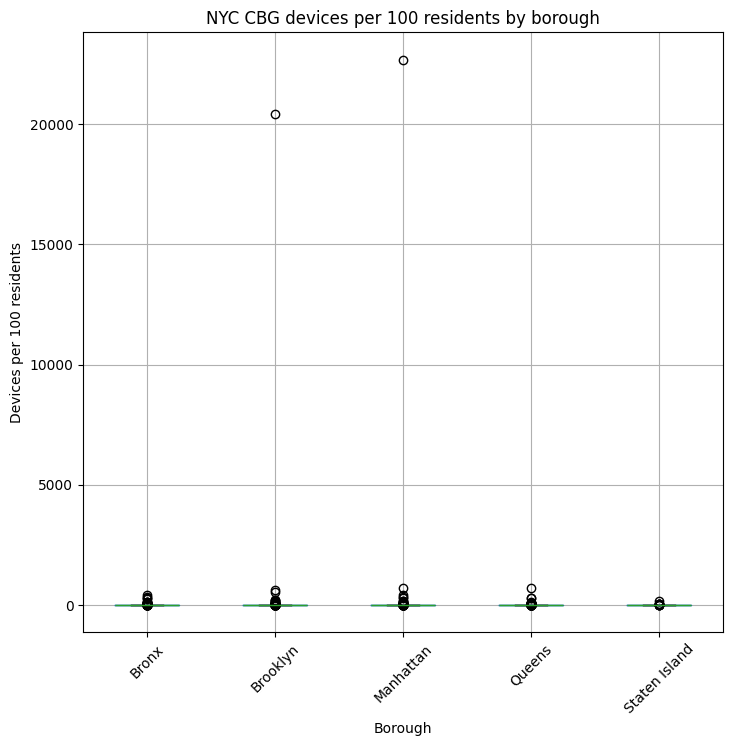

NYC Figure D: Log representation ratio by borough


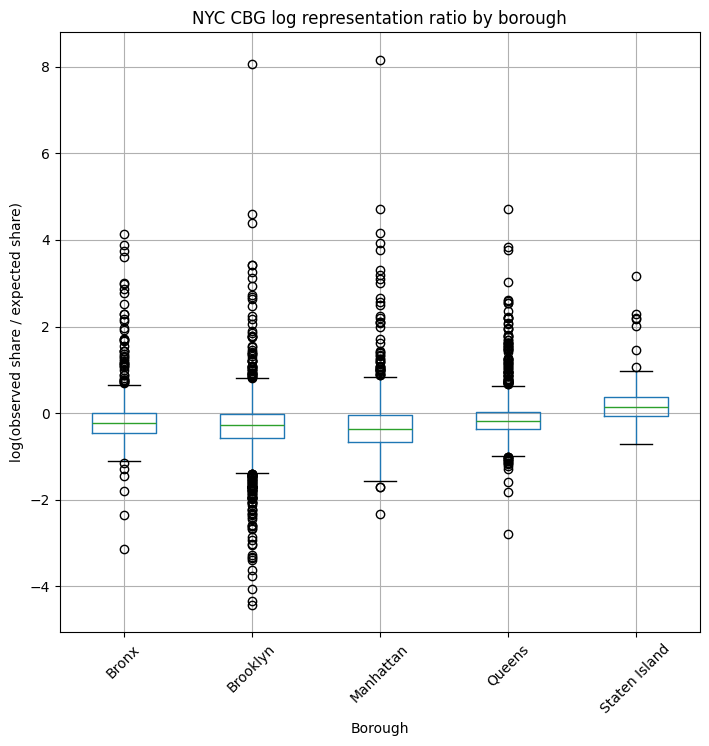

In [47]:
# Distribution diagnostics: devices per 100 residents and representation ratio by borough
print("NYC Figure C: Devices per 100 residents by borough")
ax = nyc_join_df.boxplot(column='devices_per_100_residents', by='borough', rot=45)
ax.set_title('NYC CBG devices per 100 residents by borough')
ax.set_xlabel('Borough')
ax.set_ylabel('Devices per 100 residents')
plt.suptitle('')
plt.show()

print("NYC Figure D: Log representation ratio by borough")
ax = nyc_join_df.replace([np.inf, -np.inf], np.nan).boxplot(column='log_representation_ratio', by='borough', rot=45)
ax.set_title('NYC CBG log representation ratio by borough')
ax.set_xlabel('Borough')
ax.set_ylabel('log(observed share / expected share)')
plt.suptitle('')
plt.show()

In [48]:
# NYC demographic representativeness helper.
# This mirrors the original race/education/income approach:
# devices in each CBG are allocated to demographic categories according to Census proportions in that CBG.

def demographic_representativeness(base_df, demo_df, demo_cols, denominator_col='census_population',
                                   label_col='field_level_2'):
    demo_base = pd.merge(
        base_df[['census_block_group', 'number_devices_residing', 'census_population', 'borough']],
        demo_df[['census_block_group'] + demo_cols],
        how='inner',
        on='census_block_group'
    )

    # For income, denominator_col can be a temporary column such as total_households.
    denom = demo_base[denominator_col]
    for col in demo_cols:
        demo_base[col + '_panel'] = np.where(
            denom > 0,
            demo_base['number_devices_residing'] * demo_base[col] / denom,
            np.nan
        )

    summs = sum_and_wrangle_demo_counts(demo_base, demo_cols)
    summs = pd.merge(
        summs,
        cbg_field_desc[['table_id', label_col]].drop_duplicates(),
        how='left',
        on='table_id'
    )
    summs['bias'] = compute_bias(summs, sample_var_col='count_panel', pop_var_col='count_census')
    summs['abs_bias'] = summs['bias'].abs()
    summs['representation_ratio'] = (
        (summs['count_panel'] / summs['count_panel'].sum()) /
        (summs['count_census'] / summs['count_census'].sum())
    )
    return summs.sort_values('abs_bias', ascending=False)


def income_representativeness(base_df, inc_df, inc_cols):
    """Household-income representativeness using household counts as the denominator."""
    inc_temp = inc_df.copy()
    inc_temp['total_households_for_income'] = inc_temp[inc_cols].sum(axis=1)

    income_base = pd.merge(
        base_df[['census_block_group', 'number_devices_residing', 'census_population', 'borough']],
        inc_temp[['census_block_group', 'total_households_for_income'] + inc_cols],
        how='inner',
        on='census_block_group'
    )

    for col in inc_cols:
        income_base[col + '_panel'] = np.where(
            income_base['total_households_for_income'] > 0,
            income_base['number_devices_residing'] * income_base[col] / income_base['total_households_for_income'],
            np.nan
        )

    inc_raw = sum_and_wrangle_demo_counts(income_base, inc_cols)
    inc_summary = pd.merge(
        inc_raw,
        cbg_field_desc[['table_id', 'field_level_2']].drop_duplicates(),
        how='left',
        on='table_id'
    )
    inc_summary['bias'] = compute_bias(inc_summary, sample_var_col='count_panel', pop_var_col='count_census')
    inc_summary['abs_bias'] = inc_summary['bias'].abs()
    inc_summary['representation_ratio'] = (
        (inc_summary['count_panel'] / inc_summary['count_panel'].sum()) /
        (inc_summary['count_census'] / inc_summary['count_census'].sum())
    )
    return inc_summary.sort_values('abs_bias', ascending=False)

# Full NYC CBG demographic representativeness
nyc_race = demographic_representativeness(nyc_join_df, race_census_data, race_table_ids)
nyc_edu = demographic_representativeness(nyc_join_df, edu_census_data, edu_table_ids)
nyc_inc = income_representativeness(nyc_join_df, inc_census_data, inc_table_ids)

print("NYC race representativeness, all CBGs")
display(nyc_race)

print("NYC education representativeness, all CBGs")
display(nyc_edu)

print("NYC household-income representativeness, all CBGs")
display(nyc_inc)

# Filtered NYC CBG demographic representativeness for robustness / sensitivity checks
nyc_race_filtered = demographic_representativeness(nyc_join_df_filtered, race_census_data, race_table_ids)
nyc_edu_filtered = demographic_representativeness(nyc_join_df_filtered, edu_census_data, edu_table_ids)
nyc_inc_filtered = income_representativeness(nyc_join_df_filtered, inc_census_data, inc_table_ids)

print("NYC race representativeness, filtered residential CBGs")
display(nyc_race_filtered)

print("NYC education representativeness, filtered residential CBGs")
display(nyc_edu_filtered)

print("NYC household-income representativeness, filtered residential CBGs")
display(nyc_inc_filtered)


NYC race representativeness, all CBGs


,table_id,count_census,count_panel,field_level_2,bias,abs_bias,representation_ratio
1,B02001e3,2064927.0,141187.730602,Black Or African American Alone,1.977559,1.977559,1.081039
3,B02001e5,1159883.0,68816.239040,Asian Alone,-0.849150,0.849150,0.938050
0,B02001e2,3644982.0,227527.070357,White Alone,-0.562933,0.562933,0.986931
5,B02001e7,1277265.0,78195.515345,Some Other Race Alone,-0.483865,0.483865,0.967944
6,B02001e8,277521.0,17189.226892,Two Or More Races,-0.067933,0.067933,0.979286
2,B02001e4,33388.0,1997.992943,American Indian And Alaska Native Alone,-0.021254,0.021254,0.946134
4,B02001e6,3995.0,293.224822,Native Hawaiian And Other Pacific Islander Alone,0.007576,0.007576,1.160468


NYC education representativeness, all CBGs


,table_id,count_census,count_panel,field_level_2,bias,abs_bias,representation_ratio
12,B15003e21,375851.0,25693.524212,Associate'S Degree,0.510872,0.510872,1.079540
7,B15003e17,1188696.0,76373.969482,Regular High School Diploma,0.297068,0.297068,1.014624
14,B15003e23,610225.0,37589.325519,Master'S Degree,-0.284072,0.284072,0.972759
13,B15003e22,1246538.0,78020.809949,Bachelor'S Degree,-0.246964,0.246964,0.988406
11,B15003e20,632760.0,40963.820755,"Some College, 1 Or More Years, No Degree",0.241482,0.241482,1.022332
8,B15003e18,214018.0,14296.837815,Ged Or Alternative Credential,0.200867,0.200867,1.054922
6,B15003e16,173909.0,10434.875827,"12Th Grade, No Diploma",-0.155917,0.155917,0.947536
16,B15003e25,85065.0,4854.379916,Doctorate Degree,-0.143645,0.143645,0.901184
0,B15003e10,122882.0,7253.693621,6Th Grade,-0.142408,0.142408,0.932184
15,B15003e24,177697.0,10737.956076,Professional School Degree,-0.138859,0.138859,0.954272


NYC household-income representativeness, all CBGs


...

,table_id,count_census,count_panel,field_level_2,bias,abs_bias,representation_ratio
1,B02001e3,2064093.0,138679.668840,Black Or African American Alone,1.675771,1.675771,1.068592
3,B02001e5,1159621.0,68778.001156,Asian Alone,-0.777870,0.777870,0.943326
5,B02001e7,1276883.0,78062.997715,Some Other Race Alone,-0.417885,0.417885,0.972350
0,B02001e2,3633329.0,226485.151005,White Alone,-0.368407,0.368407,0.991433
6,B02001e8,277394.0,16907.157068,Two Or More Races,-0.100475,0.100475,0.969398
2,B02001e4,33384.0,1997.799395,American Indian And Alaska Native Alone,-0.019049,0.019049,0.951792
4,B02001e6,3995.0,293.224822,Native Hawaiian And Other Pacific Islander Alone,0.007915,0.007915,1.167381


NYC education representativeness, filtered residential CBGs


,table_id,count_census,count_panel,field_level_2,bias,abs_bias,representation_ratio
7,B15003e17,1186250.0,75779.936249,Regular High School Diploma,0.328777,0.328777,1.016201
11,B15003e20,631855.0,40879.389816,"Some College, 1 Or More Years, No Degree",0.315345,0.315345,1.029174
14,B15003e23,610033.0,37511.905189,Master'S Degree,-0.227740,0.227740,0.978177
8,B15003e18,213840.0,14272.471625,Ged Or Alternative Credential,0.225800,0.225800,1.061725
16,B15003e25,85008.0,4808.733831,Doctorate Degree,-0.145634,0.145634,0.899855
6,B15003e16,173569.0,10386.637553,"12Th Grade, No Diploma",-0.142735,0.142735,0.951929
13,B15003e22,1245942.0,77839.255188,Bachelor'S Degree,-0.131974,0.131974,0.993808
0,B15003e10,122788.0,7239.470205,6Th Grade,-0.130461,0.130461,0.937891
15,B15003e24,177540.0,10717.957855,Professional School Degree,-0.120505,0.120505,0.960324
3,B15003e13,122072.0,7304.402680,9Th Grade,-0.100543,0.100543,0.951854


NYC household-income representativeness, filtered residential CBGs


,table_id,count_census,count_panel,field_level_2,bias,abs_bias,representation_ratio
7,B19001e17,260391.0,39274.668861,"$200,000 Or More",-0.933774,0.933774,0.887921
8,B19001e2,318371.0,56097.169971,"Less Than $10,000",0.379730,0.379730,1.037278
6,B19001e16,191014.0,30724.470459,"$150,000 To $199,999",-0.324490,0.324490,0.946906
10,B19001e4,166801.0,29902.099230,"$15,000 To $19,999",0.295322,0.295322,1.055336
3,B19001e13,342232.0,59225.836610,"$75,000 To $99,999",0.205584,0.205584,1.018775
14,B19001e8,124115.0,22131.203418,"$35,000 To $39,999",0.197396,0.197396,1.049708
4,B19001e14,249064.0,41262.313124,"$100,000 To $124,999",-0.196976,0.196976,0.975282
13,B19001e7,136360.0,23996.800813,"$30,000 To $34,999",0.157005,0.157005,1.035986
9,B19001e3,186247.0,32330.394547,"$10,000 To $14,999",0.130517,0.130517,1.021902
11,B19001e5,150410.0,26220.984271,"$20,000 To $24,999",0.126404,0.126404,1.026266


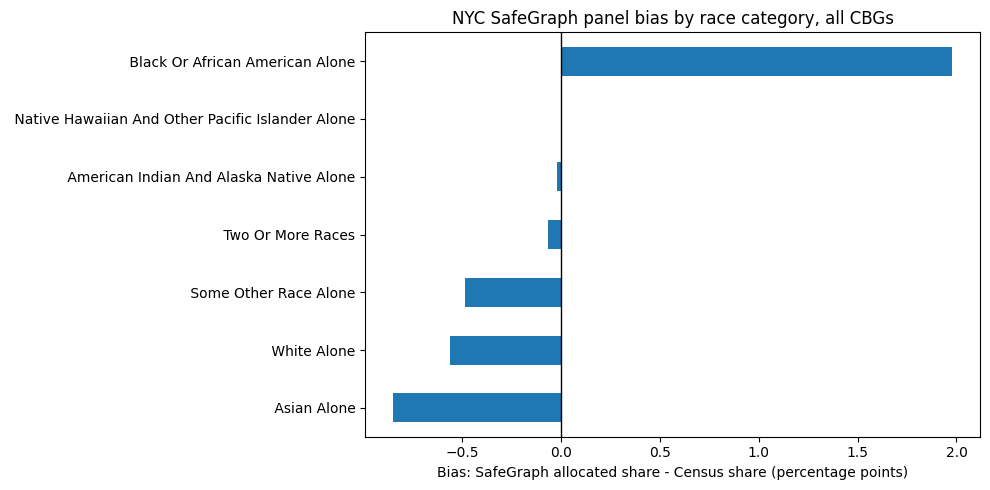

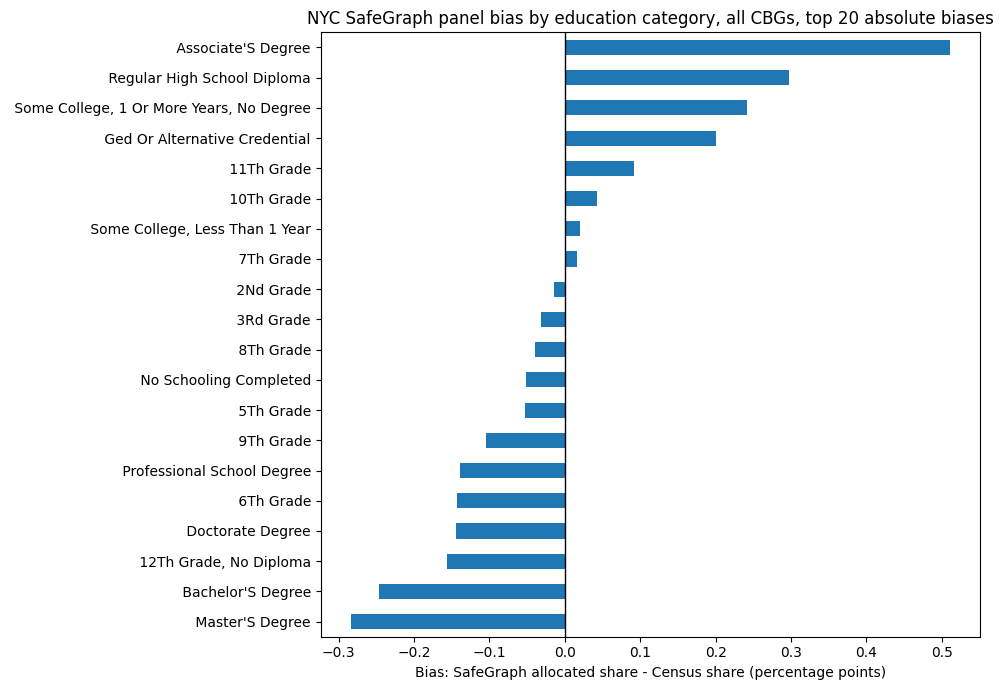

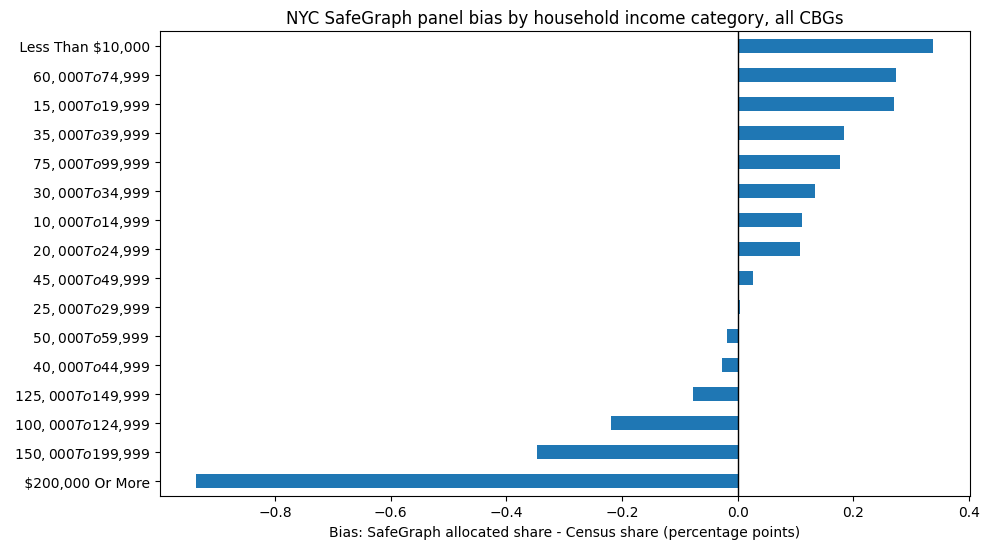

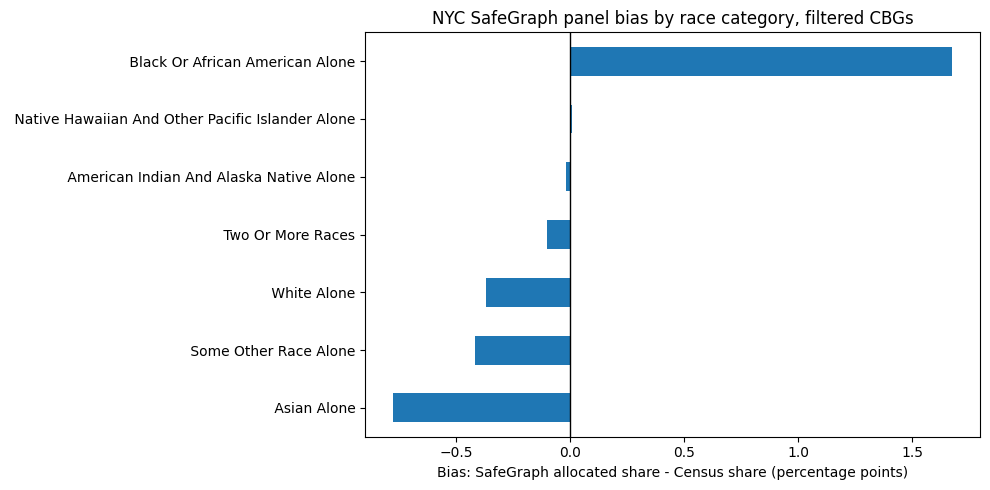

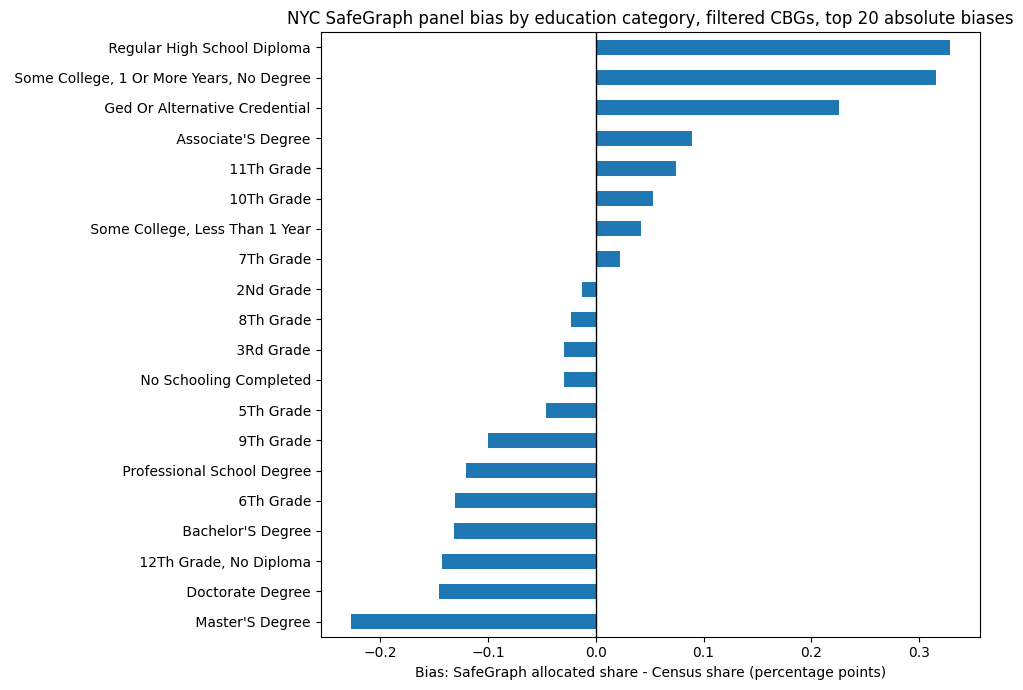

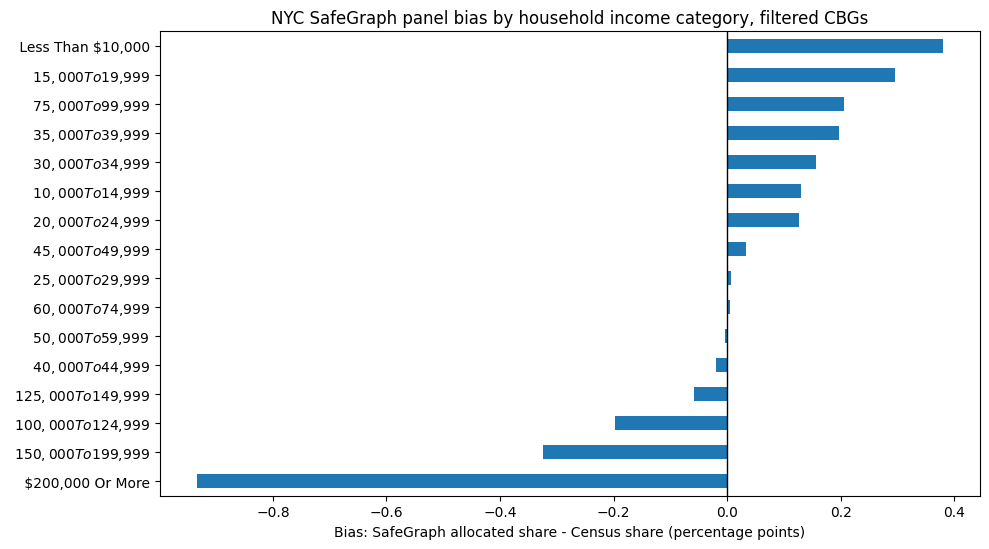

In [49]:
# Plotting NYC demographic representativeness summaries

def plot_demo_bias(summary_df, label_col='field_level_2', title=''):
    plot_df = summary_df.copy().sort_values('bias')
    ax = plot_df.plot.barh(x=label_col, y='bias', legend=False, figsize=(10, max(5, len(plot_df) * 0.35)))
    ax.axvline(0, color='k', linewidth=1)
    ax.set_xlabel('Bias: SafeGraph allocated share - Census share (percentage points)')
    ax.set_ylabel('')
    ax.set_title(title)
    plt.tight_layout()
    return ax

plot_demo_bias(nyc_race, title='NYC SafeGraph panel bias by race category, all CBGs')
plt.show()

plot_demo_bias(nyc_edu.head(20), title='NYC SafeGraph panel bias by education category, all CBGs, top 20 absolute biases')
plt.show()

plot_demo_bias(nyc_inc, title='NYC SafeGraph panel bias by household income category, all CBGs')
plt.show()

plot_demo_bias(nyc_race_filtered, title='NYC SafeGraph panel bias by race category, filtered CBGs')
plt.show()

plot_demo_bias(nyc_edu_filtered.head(20), title='NYC SafeGraph panel bias by education category, filtered CBGs, top 20 absolute biases')
plt.show()

plot_demo_bias(nyc_inc_filtered, title='NYC SafeGraph panel bias by household income category, filtered CBGs')
plt.show()


In [50]:
# Analyzing NYC CBG visit data to compare home-panel representativeness with visit-volume representativeness.

visits_path = DATA_DIR / 'nyc_cbg_with_visits_all_years.csv'

if visits_path.exists():
    visits = pd.read_csv(visits_path, low_memory=False)

    # Flexible CBG column detection
    possible_cbg_cols = ['census_block_group', 'cbg', 'visitor_home_cbg', 'home_cbg', 'GEOID', 'geoid']
    cbg_col = next((c for c in possible_cbg_cols if c in visits.columns), None)

    if cbg_col is None:
        print("Visit file found, but no recognizable CBG/GEOID column was found.")
        print("Columns:", list(visits.columns))
    else:
        visits[cbg_col] = normalize_cbg(visits[cbg_col])

        # Flexible visit-count column detection
        numeric_cols = visits.select_dtypes(include=[np.number]).columns.tolist()
        candidate_visit_cols = [
            c for c in numeric_cols
            if any(token in c.lower() for token in ['visit', 'visitor', 'raw_visit_counts', 'count'])
        ]

        if len(candidate_visit_cols) == 0:
            print("Visit file found, but no numeric visit/count column was detected.")
            print("Numeric columns:", numeric_cols)
        else:
            visit_col = candidate_visit_cols[0]
            print(f"Using CBG column: {cbg_col}")
            print(f"Using visit/count column: {visit_col}")

            visit_cbg = (
                visits.groupby(cbg_col, as_index=False)[visit_col]
                .sum()
                .rename(columns={cbg_col: 'census_block_group', visit_col: 'total_visits'})
            )

            nyc_visit_rep = pd.merge(
                nyc_join_df,
                visit_cbg,
                how='left',
                on='census_block_group'
            )
            nyc_visit_rep['total_visits'] = nyc_visit_rep['total_visits'].fillna(0)
            nyc_visit_rep = add_representativeness_metrics(
                nyc_visit_rep.rename(columns={'total_visits': 'safegraph_visits'}),
                sample_col='safegraph_visits',
                pop_col='census_population'
            )

            print("NYC visit-volume representativeness summary:")
            display(nyc_visit_rep[['census_block_group', 'borough', 'census_population',
                                   'number_devices_residing', 'safegraph_visits',
                                   'devices_per_100_residents', 'bias', 'representation_ratio']]
                    .sort_values('abs_bias', ascending=False).head(20))

            ax = plot_sg_vs_census(
                nyc_visit_rep,
                'census_population',
                'safegraph_visits',
                text_col='borough',
                num_to_label=0,
                alpha=0.35,
                title='NYC CBG-level SafeGraph visits vs Census population'
            )
            ax.set_xlabel('Census population')
            ax.set_ylabel('SafeGraph visits')
else:
    print(f"Optional visit file not found: {visits_path}")

Optional visit file not found: data/nyc_cbg_with_visits_all_years.csv


In [51]:
try:
    import geopandas as gpd
    from libpysal.weights import Queen
    from esda.moran import Moran, Moran_Local

    geo_path = DATA_DIR / 'nyc_cbgs_filtered.csv'

    if not geo_path.exists():
        print(f"Geometry file not found: {geo_path}")
    else:
        geo = pd.read_csv(geo_path, low_memory=False)

        possible_geo_cbg_cols = ['census_block_group', 'cbg', 'GEOID', 'geoid']
        geo_cbg_col = next((c for c in possible_geo_cbg_cols if c in geo.columns), None)
        if geo_cbg_col is None:
            print("No CBG/GEOID column detected in nyc_cbgs_filtered.csv.")
            print("Columns:", list(geo.columns))
        else:
            geo[geo_cbg_col] = normalize_cbg(geo[geo_cbg_col])
            geo = geo.rename(columns={geo_cbg_col: 'census_block_group'})

            if 'geometry' in geo.columns:
                # Assumes WKT if geometry is text.
                if geo['geometry'].dtype == object:
                    from shapely import wkt
                    geo['geometry'] = geo['geometry'].apply(wkt.loads)
                gdf = gpd.GeoDataFrame(geo, geometry='geometry', crs='EPSG:4326')
            elif {'longitude', 'latitude'}.issubset(set(geo.columns)):
                gdf = gpd.GeoDataFrame(
                    geo,
                    geometry=gpd.points_from_xy(geo['longitude'], geo['latitude']),
                    crs='EPSG:4326'
                )
            else:
                print("No geometry column or longitude/latitude columns detected.")
                print("Columns:", list(geo.columns))
                gdf = None

            if gdf is not None:
                gdf = gdf.merge(
                    nyc_join_df[['census_block_group', 'borough', 'log_representation_ratio',
                                 'representation_ratio', 'bias', 'census_population',
                                 'number_devices_residing']],
                    on='census_block_group',
                    how='inner'
                )
                gdf = gdf.replace([np.inf, -np.inf], np.nan).dropna(subset=['log_representation_ratio'])

                if len(gdf) < 3:
                    print("Not enough valid NYC CBG geometries for Moran's I.")
                else:
                    weights = Queen.from_dataframe(gdf)
                    weights.transform = 'r'
                    y = gdf['log_representation_ratio'].values

                    moran = Moran(y, weights)
                    print(f"Global Moran's I for NYC CBG log representation ratio: {moran.I:.4f}")
                    print(f"Permutation p-value: {moran.p_sim:.4f}")

                    local = Moran_Local(y, weights)
                    gdf['local_moran_I'] = local.Is
                    gdf['local_moran_p'] = local.p_sim
                    gdf['local_cluster'] = 'Not significant'

                    high = y > np.nanmean(y)
                    lag_y = weights.sparse @ y
                    high_lag = lag_y > np.nanmean(y)

                    gdf.loc[(local.p_sim < 0.05) & high & high_lag, 'local_cluster'] = 'High-High'
                    gdf.loc[(local.p_sim < 0.05) & (~high) & (~high_lag), 'local_cluster'] = 'Low-Low'
                    gdf.loc[(local.p_sim < 0.05) & high & (~high_lag), 'local_cluster'] = 'High-Low'
                    gdf.loc[(local.p_sim < 0.05) & (~high) & high_lag, 'local_cluster'] = 'Low-High'

                    print("Local Moran cluster counts:")
                    display(gdf['local_cluster'].value_counts().reset_index().rename(columns={'index': 'cluster', 'local_cluster': 'count'}))

                    moran_out = OUTPUT_DIR / 'nyc_cbg_moran_results.csv'
                    gdf.drop(columns='geometry').to_csv(moran_out, index=False)
                    print(f"Saved Moran results to: {moran_out}")

except ImportError as e:
    print("Skipping Moran's I because a required package is not installed.")
    print("Install if needed: pip install geopandas libpysal esda shapely")
    print("Import error:", e)

Skipping Moran's I because a required package is not installed.
Install if needed: pip install geopandas libpysal esda shapely
Import error: No module named 'geopandas'


In [52]:
# Save Full NYC CBG outputs
nyc_join_df.to_csv(OUTPUT_DIR / 'nyc_cbg_representativeness_metrics.csv', index=False)
nyc_borough.to_csv(OUTPUT_DIR / 'nyc_borough_representativeness_metrics.csv', index=False)
nyc_race.to_csv(OUTPUT_DIR / 'nyc_race_representativeness_metrics.csv', index=False)
nyc_edu.to_csv(OUTPUT_DIR / 'nyc_education_representativeness_metrics.csv', index=False)
nyc_inc.to_csv(OUTPUT_DIR / 'nyc_income_representativeness_metrics.csv', index=False)

# Filtered / sensitivity outputs
nyc_join_df_filtered.to_csv(OUTPUT_DIR / 'nyc_cbg_representativeness_metrics_filtered.csv', index=False)
nyc_borough_filtered.to_csv(OUTPUT_DIR / 'nyc_borough_representativeness_metrics_filtered.csv', index=False)
nyc_sensitivity_summary.to_csv(OUTPUT_DIR / 'nyc_sensitivity_filter_summary.csv', index=False)
nyc_race_filtered.to_csv(OUTPUT_DIR / 'nyc_race_representativeness_metrics_filtered.csv', index=False)
nyc_edu_filtered.to_csv(OUTPUT_DIR / 'nyc_education_representativeness_metrics_filtered.csv', index=False)
nyc_inc_filtered.to_csv(OUTPUT_DIR / 'nyc_income_representativeness_metrics_filtered.csv', index=False)

print("Saved full and filtered NYC representativeness outputs to the outputs/ folder.")


Saved full and filtered NYC representativeness outputs to the outputs/ folder.
